# Toy noise benchmark: tangent alignment and containment

Read the saved [metrics database](../outputs/experiments/toy_noise_sweep_metrics/README.md)
and plot **Alignment** (`tangent_alignment__subspace_overlap__mean`) and
**Containment** (`tangent_containment__subspace_overlap__mean`).
The first heatmap shows alignment; the containment heatmap follows below.
For a tangent of intrinsic dimension $r$, this is the component mean of
$\frac{1}{r}\sum_{j=1}^{r}\cos^2\theta_j$, comparing the exact tangent with
the leading $r$ covariance PCs (empirical cluster PCs for KM). Higher is better;
the color scale is fixed to $[0,1]$.

Rows show `(r,m)`: intrinsic dimension and native embedding dimension, rather
than the common ambient dimension $D=128$. Noise ratios decrease left to right:
$\sigma=R_{\mathrm{curvature}}/\mathrm{noise\_ratio}$, so noise increases.

The database contains overall and per-manifold rows keyed by `evaluation_id`,
with sweeps over noise ratio, component count `K`, HDDC surgery threshold,
and KM Cattell threshold. KM also has distinct PCA capacities.

The configuration below holds **`K=250`**, model capacity **32**, KM PCA
capacity **32**, and both thresholds **0.01** fixed, using the
three-model layout at noise ratios **1000, 100, 10**. Noise ratio **10000** is
excluded at load time throughout this notebook. Change `NOISE_RATIOS`,
`K`, `MODEL_Q_CAPACITY`, `KM_PCA_CAPACITY`, `HDDC_THRESHOLD`, and
`KM_CATTELL_THRESHOLD` to select another slice. The coverage table counts
matching evaluations before restricting noise; every requested model/noise
combination must have exactly one evaluation. Missing or duplicate settings fail
explicitly instead of being dropped or averaged.

For each noise ratio, select the **HDDC run at `HDDC_THRESHOLD`**. MFA is
selected at the same `K` and model capacity. KM uses `KM_CATTELL_THRESHOLD`
and `KM_PCA_CAPACITY` at every noise ratio.
KM alignment is independent of this threshold, which is verified below;
KM containment uses the rank selected by this threshold. Each heatmap cell is one saved per-manifold mean, with no averaging
across thresholds. Undefined means remain missing and appear as `NA`.

In [29]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# Works with the kernel started in the repository root or notebooks/.
REPO = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "pyproject.toml").is_file())
DATA_DIR = REPO / "outputs/experiments/toy_noise_sweep_metrics"
PLOT_DIR = DATA_DIR / "plots"
METRIC = "tangent_alignment__subspace_overlap__mean"
VALID = "tangent_alignment__subspace_overlap__valid_components"
UNDEFINED = "tangent_alignment__subspace_overlap__undefined_components"
# Fixed slice through the larger sweep (noise increases left to right).
K = 250
MODEL_Q_CAPACITY = 32
# Saved KM capacity is 32 for K=250/500/2000; use 16 for K=1000 across all noise ratios.
KM_PCA_CAPACITY = 32
NOISE_RATIOS = [1000, 100, 10]
HDDC_THRESHOLD = 0.01
KM_CATTELL_THRESHOLD = 0.01
MODEL_LABELS = {"kmeans": "KM", "mfa": "MFA", "hddc": "HDDC"}

metrics = pd.read_parquet(DATA_DIR / "metrics.parquet")
# Exclude noise ratio 10000 before any selection or aggregation.
metrics = metrics.loc[~metrics["noise_ratio"].eq(10000).fillna(False)].copy()
# Exclude surgery-threshold-1 runs before any selection or aggregation.
metrics = metrics.loc[~metrics["surgery_threshold"].eq(1).fillna(False)].copy()
overall = metrics.loc[metrics["scope"].eq("overall")].copy()
manifolds = metrics.loc[metrics["scope"].eq("manifold")].copy()
assert not metrics.duplicated(["evaluation_id", "manifold_id"]).any()
noise_ratios = sorted(NOISE_RATIOS, reverse=True)
assert noise_ratios and len(noise_ratios) == len(set(noise_ratios))
print(f"Loaded {len(metrics)} rows, {len(overall)} evaluation settings.")
print(f"Available K: {sorted(overall['K'].unique())}; noise ratios: {sorted(overall['noise_ratio'].unique(), reverse=True)}")
print(f"Selected K={K}; noise ratios (in plot order): {noise_ratios}")

Loaded 2541 rows, 231 evaluation settings.
Available K: [np.int64(250), np.int64(500), np.int64(1000), np.int64(2000)]; noise ratios: [np.float64(1000.0), np.float64(100.0), np.float64(10.0)]
Selected K=250; noise ratios (in plot order): [1000, 100, 10]


## Run comparison tables per manifold

Each table contains one row per saved **evaluation configuration** for that
manifold, ordered by noise ratio (decreasing), model, K, capacity, and threshold.
By default these tables cover the whole database after the notebook's exclusion
of **noise ratio 10000** and **HDDC surgery threshold 1**. They are
independent of the heatmap slice below. Set `MANIFOLD_TABLE_FILTERS` below to
restrict configurations; for example `{"noise_ratio": [10], "K": [1000]}`.
Separate KM Cattell thresholds remain separate rows even when they reuse a partition.

The columns report the following **per-manifold** quantities:

- **Associated**, **% of K**, and **Live**: components associated by geometric
  proximity, their fraction of all K components, and how many have hard-assigned
  points. **Scored** is the population used for rank and tangent evaluation;
  KM excludes clusters below **KM min points**, while MFA/HDDC include all
  associated components, including assignment-dead ones.
- **Mean qₖ**, **qₖ = r (%)** (higher is better), and **Rank MAE** (lower is
  better): rank recovery against this manifold's intrinsic dimension r.
  qₖ is the saved mask rank for HDDC, the post-hoc effective rank for MFA, and
  raw Cattell rank for KM. Capacity columns describe the configured model/PCA
  capacity, rather than the measured rank.
- **Alignment** and **Containment**: saved mean tangent overlaps on [0, 1]
  (higher is better), each accompanied by its **valid / undefined** component
  counts. Containment should be read together with rank recovery because larger
  learned subspaces can contain more tangent directions.

All means and rates retain their recorded component populations; there is no
averaging across manifolds or configurations. `NA` preserves undefined metrics
and inapplicable settings. Seeds are shown as **run / split / dataset**. Each
table's heading gives **(intrinsic dimension r, native embedding dimension m)**.
See the [metric definitions](../docs/evaluation/toy-manifold-tiling.md).

Tables scroll in both directions and retain every row. Full-precision CSVs,
source rows with evaluation IDs and provenance, and a standalone HTML report
are exported to `PLOT_DIR / "per_manifold_tables"`.


In [30]:
# Empty filters include every saved configuration retained by the notebook.
# Example: {"noise_ratio": [10], "K": [1000], "model_kind": ["mfa", "hddc"]}
MANIFOLD_TABLE_FILTERS = {}
MANIFOLD_TABLE_DIR = PLOT_DIR / "per_manifold_tables"

# Build the identity catalog from all saved model rows; KM omits native m.
manifold_table_catalog = (
    manifolds[["manifold_id", "type_name", "intrinsic_dim", "embedding_dim"]]
    .dropna(subset=["embedding_dim"]).drop_duplicates()
    .sort_values(["intrinsic_dim", "embedding_dim", "manifold_id"])
)
assert manifold_table_catalog["manifold_id"].is_unique
manifold_table_catalog["label"] = [
    f"{row.type_name.replace('_', ' ').title()} ({int(row.intrinsic_dim)},{int(row.embedding_dim)})"
    for row in manifold_table_catalog.itertuples()
]
manifold_table_ids = set(manifold_table_catalog["manifold_id"])

manifold_table_runs = overall.copy()
for column, values in MANIFOLD_TABLE_FILTERS.items():
    manifold_table_runs = manifold_table_runs.loc[manifold_table_runs[column].isin(values)]
assert not manifold_table_runs.empty, "No evaluations match MANIFOLD_TABLE_FILTERS."
assert manifold_table_runs["evaluation_id"].is_unique

manifold_table_rows = manifolds.loc[
    manifolds["evaluation_id"].isin(manifold_table_runs["evaluation_id"])
].copy()
assert not manifold_table_rows.duplicated(["evaluation_id", "manifold_id"]).any()
assert manifold_table_rows.groupby("evaluation_id")["manifold_id"].agg(set).map(
    lambda ids: ids == manifold_table_ids
).all(), "Every evaluation must contain the shared manifold catalog."
assert set(manifold_table_rows["evaluation_id"]) == set(manifold_table_runs["evaluation_id"])

# Preserve evaluation-level definitions as context, without copying global scores.
manifold_table_context = [
    "rank__definition", "rank__population", "rank__threshold", "eligibility__min_population",
]
for column in manifold_table_context:
    manifold_table_rows[column] = manifold_table_rows["evaluation_id"].map(
        manifold_table_runs.set_index("evaluation_id")[column]
    )
manifold_table_rows["embedding_dim"] = manifold_table_rows["manifold_id"].map(
    manifold_table_catalog.set_index("manifold_id")["embedding_dim"]
)
manifold_table_rows["model"] = pd.Categorical(
    manifold_table_rows["model_kind"].map(MODEL_LABELS),
    categories=list(MODEL_LABELS.values()), ordered=True,
)
manifold_table_rows = manifold_table_rows.sort_values(
    ["noise_ratio", "model", "K", "q_capacity", "pca_capacity", "surgery_threshold",
     "cattell_threshold", "seed", "split_seed", "dataset_seed", "evaluation_id"],
    ascending=[False] + [True] * 10,
)
assert manifold_table_rows["components__associated"].eq(
    manifold_table_rows["components__assignment_live"]
    + manifold_table_rows["components__assignment_dead"]
).all()
for metric in ("tangent_alignment", "tangent_containment"):
    prefix = f"{metric}__subspace_overlap__"
    valid = manifold_table_rows[prefix + "valid_components"]
    undefined = manifold_table_rows[prefix + "undefined_components"]
    assert (valid + undefined).eq(manifold_table_rows["rank__components"]).all()
    assert manifold_table_rows[prefix + "mean"].isna().eq(valid.eq(0)).all()
    manifold_table_rows[f"{metric}_counts"] = (
        valid.astype("Int64").astype(str) + " / " + undefined.astype("Int64").astype(str)
    )

manifold_table_rows["component_pct"] = (
    100 * manifold_table_rows["components__associated"] / manifold_table_rows["K"]
)
manifold_table_rows["exact_r_pct"] = 100 * manifold_table_rows["rank__exact_match"]
manifold_table_rows["seeds"] = manifold_table_rows[
    ["seed", "split_seed", "dataset_seed"]
].astype("Int64").astype("string").fillna("NA").agg(" / ".join, axis=1)

manifold_table_columns = {
    "model": "Model", "noise_ratio": "Noise ratio", "K": "K",
    "q_capacity": "q capacity", "pca_capacity": "PCA capacity",
    "surgery_threshold": "HDDC t", "cattell_threshold": "KM t", "seeds": "Seeds",
    "eligibility__min_population": "KM min points",
    "components__associated": "Associated", "component_pct": "% of K",
    "components__assignment_live": "Live", "rank__components": "Scored",
    "rank__mean_learned": "Mean qₖ", "exact_r_pct": "qₖ = r (%)",
    "rank__mean_absolute_error": "Rank MAE",
    "tangent_alignment__subspace_overlap__mean": "Alignment",
    "tangent_alignment_counts": "Alignment valid / undefined",
    "tangent_containment__subspace_overlap__mean": "Containment",
    "tangent_containment_counts": "Containment valid / undefined",
    "evaluation_id": "Evaluation ID",
}
manifold_tables = {
    int(manifold.manifold_id): manifold_table_rows.loc[
        manifold_table_rows["manifold_id"].eq(manifold.manifold_id), list(manifold_table_columns)
    ].rename(columns=manifold_table_columns).reset_index(drop=True)
    for manifold in manifold_table_catalog.itertuples()
}
print(f"{len(manifold_tables)} manifold tables; {len(manifold_table_runs)} evaluation configurations per table.")


10 manifold tables; 231 evaluation configurations per table.


In [31]:
from html import escape
from IPython.display import HTML

manifold_table_formats = {
    "Noise ratio": "g", "K": ".0f", "q capacity": ".0f", "PCA capacity": ".0f",
    "HDDC t": "g", "KM t": "g", "KM min points": ".0f",
    "Associated": ".0f", "% of K": ".2f", "Live": ".0f", "Scored": ".0f",
    "Mean qₖ": ".2f", "qₖ = r (%)": ".1f", "Rank MAE": ".2f",
    "Alignment": ".3f", "Containment": ".3f",
}
manifold_table_css = """<style>
.manifold-comparison {font-family:system-ui,sans-serif; margin-bottom:24px}
.manifold-comparison .table-scroll {max-height:540px; overflow:auto; border:1px solid #cbd5e1}
.manifold-comparison table {border-collapse:separate; border-spacing:0; font-size:13px}
.manifold-comparison th, .manifold-comparison td {padding:7px 10px; white-space:nowrap; text-align:right}
.manifold-comparison thead th {position:sticky; top:0; z-index:1; background:#e2e8f0; color:#1e293b}
.manifold-comparison tbody tr:nth-child(even) {background:#f1f5f9; color:#1e293b}
.manifold-comparison tbody tr:hover {background:#dbeafe; color:#1e293b}
.manifold-comparison th:first-child, .manifold-comparison td:first-child {text-align:left}
</style>"""
manifold_table_sections = []
MANIFOLD_TABLE_DIR.mkdir(parents=True, exist_ok=True)
for manifold in manifold_table_catalog.itertuples():
    table = manifold_tables[int(manifold.manifold_id)]
    formatted = table.copy()
    for column, spec in manifold_table_formats.items():
        formatted[column] = table[column].map(
            lambda value: "NA" if pd.isna(value) else format(value, spec)
        )
    section = (
        '<section class="manifold-comparison">'
        f'<h3>{escape(manifold.label)} · manifold {int(manifold.manifold_id)}</h3>'
        f'<p>{len(table)} evaluation configurations. Seeds: run / split / dataset. '
        'Tangent counts: valid / undefined. NA: undefined or inapplicable.</p>'
        '<div class="table-scroll">'
        + formatted.to_html(index=False, border=0, escape=True, max_rows=None, max_cols=None)
        + '</div></section>'
    )
    display(HTML(manifold_table_css + section))
    manifold_table_sections.append(section)
    table.to_csv(
        MANIFOLD_TABLE_DIR / f"manifold_{int(manifold.manifold_id):02d}_{manifold.type_name}.csv",
        index=False,
    )

# Source rows preserve numeric precision, definitions, and source paths/hashes.
manifold_table_rows.to_csv(MANIFOLD_TABLE_DIR / "source_rows.csv", index=False)
manifold_table_report = (
    '<!doctype html><html><head><meta charset="utf-8">'
    '<title>Toy noise: per-manifold run comparisons</title>'
    + manifold_table_css + '</head><body>'
    '<h1>Toy noise: per-manifold run comparisons</h1>'
    f'<p>Filters: {escape(str(MANIFOLD_TABLE_FILTERS))}. Noise ratio 10000 and HDDC surgery threshold 1 excluded.</p>'
    '<p>All metrics are per manifold. Rank recovery targets intrinsic dimension r; '
    'headings show (r, native embedding dimension m). KM uses raw Cattell rank on '
    'eligible clusters, MFA uses post-hoc effective rank, and HDDC uses saved mask rank. '
    'Rank MAE is lower-is-better; exact rank match and tangent overlaps are higher-is-better. '
    'Containment can increase with learned rank. Means exclude undefined components.</p>'
    + "\n".join(manifold_table_sections) + '</body></html>'
)
(MANIFOLD_TABLE_DIR / "index.html").write_text(manifold_table_report, encoding="utf-8")
print(f"Saved {len(manifold_tables)} CSV tables, source rows, and HTML report to {MANIFOLD_TABLE_DIR.relative_to(REPO)}")


Model,Noise ratio,K,q capacity,PCA capacity,HDDC t,KM t,Seeds,KM min points,Associated,% of K,Live,Scored,Mean qₖ,qₖ = r (%),Rank MAE,Alignment,Alignment valid / undefined,Containment,Containment valid / undefined,Evaluation ID
KM,1000,250,32,32,NA,0.00025,0 / NA / 0,33,7,2.80,7,7,1.00,100.0,0.00,1.000,7 / 0,1.000,7 / 0,kmeans::noise_ratio_1000/centroids/kmeans_k250_full/initialization_evaluation::cattell=0.00025
KM,1000,250,32,32,NA,0.005,0 / NA / 0,33,7,2.80,7,7,1.00,100.0,0.00,1.000,7 / 0,1.000,7 / 0,kmeans::noise_ratio_1000/centroids/kmeans_k250_full/initialization_evaluation::cattell=0.005
KM,1000,250,32,32,NA,0.01,0 / NA / 0,33,7,2.80,7,7,1.00,100.0,0.00,1.000,7 / 0,1.000,7 / 0,kmeans::noise_ratio_1000/centroids/kmeans_k250_full/initialization_evaluation::cattell=0.01
KM,1000,250,32,32,NA,0.05,0 / NA / 0,33,7,2.80,7,7,1.00,100.0,0.00,1.000,7 / 0,1.000,7 / 0,kmeans::noise_ratio_1000/centroids/kmeans_k250_full/initialization_evaluation::cattell=0.05
KM,1000,250,32,32,NA,0.1,0 / NA / 0,33,7,2.80,7,7,1.00,100.0,0.00,1.000,7 / 0,1.000,7 / 0,kmeans::noise_ratio_1000/centroids/kmeans_k250_full/initialization_evaluation::cattell=0.1
KM,1000,250,32,32,NA,0.15,0 / NA / 0,33,7,2.80,7,7,1.00,100.0,0.00,1.000,7 / 0,1.000,7 / 0,kmeans::noise_ratio_1000/centroids/kmeans_k250_full/initialization_evaluation::cattell=0.15
KM,1000,250,32,32,NA,0.2,0 / NA / 0,33,7,2.80,7,7,1.00,100.0,0.00,1.000,7 / 0,1.000,7 / 0,kmeans::noise_ratio_1000/centroids/kmeans_k250_full/initialization_evaluation::cattell=0.2
KM,1000,250,32,32,NA,0.5,0 / NA / 0,33,7,2.80,7,7,1.00,100.0,0.00,1.000,7 / 0,1.000,7 / 0,kmeans::noise_ratio_1000/centroids/kmeans_k250_full/initialization_evaluation::cattell=0.5
KM,1000,250,32,32,NA,1,0 / NA / 0,33,7,2.80,7,7,1.00,100.0,0.00,1.000,7 / 0,1.000,7 / 0,kmeans::noise_ratio_1000/centroids/kmeans_k250_full/initialization_evaluation::cattell=1.0
KM,1000,500,32,32,NA,0.00025,0 / NA / 0,33,10,2.00,10,10,1.00,100.0,0.00,1.000,10 / 0,1.000,10 / 0,kmeans::noise_ratio_1000/centroids/kmeans_k500_full/initialization_evaluation::cattell=0.00025


Model,Noise ratio,K,q capacity,PCA capacity,HDDC t,KM t,Seeds,KM min points,Associated,% of K,Live,Scored,Mean qₖ,qₖ = r (%),Rank MAE,Alignment,Alignment valid / undefined,Containment,Containment valid / undefined,Evaluation ID
KM,1000,250,32,32,NA,0.00025,0 / NA / 0,33,9,3.60,9,9,2.00,0.0,1.00,1.000,9 / 0,1.000,9 / 0,kmeans::noise_ratio_1000/centroids/kmeans_k250_full/initialization_evaluation::cattell=0.00025
KM,1000,250,32,32,NA,0.005,0 / NA / 0,33,9,3.60,9,9,2.00,0.0,1.00,1.000,9 / 0,1.000,9 / 0,kmeans::noise_ratio_1000/centroids/kmeans_k250_full/initialization_evaluation::cattell=0.005
KM,1000,250,32,32,NA,0.01,0 / NA / 0,33,9,3.60,9,9,1.00,100.0,0.00,1.000,9 / 0,1.000,9 / 0,kmeans::noise_ratio_1000/centroids/kmeans_k250_full/initialization_evaluation::cattell=0.01
KM,1000,250,32,32,NA,0.05,0 / NA / 0,33,9,3.60,9,9,1.00,100.0,0.00,1.000,9 / 0,1.000,9 / 0,kmeans::noise_ratio_1000/centroids/kmeans_k250_full/initialization_evaluation::cattell=0.05
KM,1000,250,32,32,NA,0.1,0 / NA / 0,33,9,3.60,9,9,1.00,100.0,0.00,1.000,9 / 0,1.000,9 / 0,kmeans::noise_ratio_1000/centroids/kmeans_k250_full/initialization_evaluation::cattell=0.1
KM,1000,250,32,32,NA,0.15,0 / NA / 0,33,9,3.60,9,9,1.00,100.0,0.00,1.000,9 / 0,1.000,9 / 0,kmeans::noise_ratio_1000/centroids/kmeans_k250_full/initialization_evaluation::cattell=0.15
KM,1000,250,32,32,NA,0.2,0 / NA / 0,33,9,3.60,9,9,1.00,100.0,0.00,1.000,9 / 0,1.000,9 / 0,kmeans::noise_ratio_1000/centroids/kmeans_k250_full/initialization_evaluation::cattell=0.2
KM,1000,250,32,32,NA,0.5,0 / NA / 0,33,9,3.60,9,9,1.00,100.0,0.00,1.000,9 / 0,1.000,9 / 0,kmeans::noise_ratio_1000/centroids/kmeans_k250_full/initialization_evaluation::cattell=0.5
KM,1000,250,32,32,NA,1,0 / NA / 0,33,9,3.60,9,9,1.00,100.0,0.00,1.000,9 / 0,1.000,9 / 0,kmeans::noise_ratio_1000/centroids/kmeans_k250_full/initialization_evaluation::cattell=1.0
KM,1000,500,32,32,NA,0.00025,0 / NA / 0,33,12,2.40,12,12,2.00,0.0,1.00,1.000,12 / 0,1.000,12 / 0,kmeans::noise_ratio_1000/centroids/kmeans_k500_full/initialization_evaluation::cattell=0.00025


Model,Noise ratio,K,q capacity,PCA capacity,HDDC t,KM t,Seeds,KM min points,Associated,% of K,Live,Scored,Mean qₖ,qₖ = r (%),Rank MAE,Alignment,Alignment valid / undefined,Containment,Containment valid / undefined,Evaluation ID
KM,1000,250,32,32,NA,0.00025,0 / NA / 0,33,17,6.80,17,17,2.00,0.0,1.00,1.000,17 / 0,1.000,17 / 0,kmeans::noise_ratio_1000/centroids/kmeans_k250_full/initialization_evaluation::cattell=0.00025
KM,1000,250,32,32,NA,0.005,0 / NA / 0,33,17,6.80,17,17,2.00,0.0,1.00,1.000,17 / 0,1.000,17 / 0,kmeans::noise_ratio_1000/centroids/kmeans_k250_full/initialization_evaluation::cattell=0.005
KM,1000,250,32,32,NA,0.01,0 / NA / 0,33,17,6.80,17,17,1.18,82.4,0.18,1.000,17 / 0,1.000,17 / 0,kmeans::noise_ratio_1000/centroids/kmeans_k250_full/initialization_evaluation::cattell=0.01
KM,1000,250,32,32,NA,0.05,0 / NA / 0,33,17,6.80,17,17,1.00,100.0,0.00,1.000,17 / 0,1.000,17 / 0,kmeans::noise_ratio_1000/centroids/kmeans_k250_full/initialization_evaluation::cattell=0.05
KM,1000,250,32,32,NA,0.1,0 / NA / 0,33,17,6.80,17,17,1.00,100.0,0.00,1.000,17 / 0,1.000,17 / 0,kmeans::noise_ratio_1000/centroids/kmeans_k250_full/initialization_evaluation::cattell=0.1
KM,1000,250,32,32,NA,0.15,0 / NA / 0,33,17,6.80,17,17,1.00,100.0,0.00,1.000,17 / 0,1.000,17 / 0,kmeans::noise_ratio_1000/centroids/kmeans_k250_full/initialization_evaluation::cattell=0.15
KM,1000,250,32,32,NA,0.2,0 / NA / 0,33,17,6.80,17,17,1.00,100.0,0.00,1.000,17 / 0,1.000,17 / 0,kmeans::noise_ratio_1000/centroids/kmeans_k250_full/initialization_evaluation::cattell=0.2
KM,1000,250,32,32,NA,0.5,0 / NA / 0,33,17,6.80,17,17,1.00,100.0,0.00,1.000,17 / 0,1.000,17 / 0,kmeans::noise_ratio_1000/centroids/kmeans_k250_full/initialization_evaluation::cattell=0.5
KM,1000,250,32,32,NA,1,0 / NA / 0,33,17,6.80,17,17,1.00,100.0,0.00,1.000,17 / 0,1.000,17 / 0,kmeans::noise_ratio_1000/centroids/kmeans_k250_full/initialization_evaluation::cattell=1.0
KM,1000,500,32,32,NA,0.00025,0 / NA / 0,33,23,4.60,23,23,2.00,0.0,1.00,1.000,23 / 0,1.000,23 / 0,kmeans::noise_ratio_1000/centroids/kmeans_k500_full/initialization_evaluation::cattell=0.00025


Model,Noise ratio,K,q capacity,PCA capacity,HDDC t,KM t,Seeds,KM min points,Associated,% of K,Live,Scored,Mean qₖ,qₖ = r (%),Rank MAE,Alignment,Alignment valid / undefined,Containment,Containment valid / undefined,Evaluation ID
KM,1000,250,32,32,NA,0.00025,0 / NA / 0,33,13,5.20,13,13,2.00,0.0,1.00,1.000,13 / 0,1.000,13 / 0,kmeans::noise_ratio_1000/centroids/kmeans_k250_full/initialization_evaluation::cattell=0.00025
KM,1000,250,32,32,NA,0.005,0 / NA / 0,33,13,5.20,13,13,2.00,0.0,1.00,1.000,13 / 0,1.000,13 / 0,kmeans::noise_ratio_1000/centroids/kmeans_k250_full/initialization_evaluation::cattell=0.005
KM,1000,250,32,32,NA,0.01,0 / NA / 0,33,13,5.20,13,13,2.00,0.0,1.00,1.000,13 / 0,1.000,13 / 0,kmeans::noise_ratio_1000/centroids/kmeans_k250_full/initialization_evaluation::cattell=0.01
KM,1000,250,32,32,NA,0.05,0 / NA / 0,33,13,5.20,13,13,1.00,100.0,0.00,1.000,13 / 0,1.000,13 / 0,kmeans::noise_ratio_1000/centroids/kmeans_k250_full/initialization_evaluation::cattell=0.05
KM,1000,250,32,32,NA,0.1,0 / NA / 0,33,13,5.20,13,13,1.00,100.0,0.00,1.000,13 / 0,1.000,13 / 0,kmeans::noise_ratio_1000/centroids/kmeans_k250_full/initialization_evaluation::cattell=0.1
KM,1000,250,32,32,NA,0.15,0 / NA / 0,33,13,5.20,13,13,1.00,100.0,0.00,1.000,13 / 0,1.000,13 / 0,kmeans::noise_ratio_1000/centroids/kmeans_k250_full/initialization_evaluation::cattell=0.15
KM,1000,250,32,32,NA,0.2,0 / NA / 0,33,13,5.20,13,13,1.00,100.0,0.00,1.000,13 / 0,1.000,13 / 0,kmeans::noise_ratio_1000/centroids/kmeans_k250_full/initialization_evaluation::cattell=0.2
KM,1000,250,32,32,NA,0.5,0 / NA / 0,33,13,5.20,13,13,1.00,100.0,0.00,1.000,13 / 0,1.000,13 / 0,kmeans::noise_ratio_1000/centroids/kmeans_k250_full/initialization_evaluation::cattell=0.5
KM,1000,250,32,32,NA,1,0 / NA / 0,33,13,5.20,13,13,1.00,100.0,0.00,1.000,13 / 0,1.000,13 / 0,kmeans::noise_ratio_1000/centroids/kmeans_k250_full/initialization_evaluation::cattell=1.0
KM,1000,500,32,32,NA,0.00025,0 / NA / 0,33,18,3.60,18,18,2.00,0.0,1.00,1.000,18 / 0,1.000,18 / 0,kmeans::noise_ratio_1000/centroids/kmeans_k500_full/initialization_evaluation::cattell=0.00025


Model,Noise ratio,K,q capacity,PCA capacity,HDDC t,KM t,Seeds,KM min points,Associated,% of K,Live,Scored,Mean qₖ,qₖ = r (%),Rank MAE,Alignment,Alignment valid / undefined,Containment,Containment valid / undefined,Evaluation ID
KM,1000,250,32,32,NA,0.00025,0 / NA / 0,33,22,8.80,22,22,3.00,0.0,1.00,1.000,22 / 0,1.000,22 / 0,kmeans::noise_ratio_1000/centroids/kmeans_k250_full/initialization_evaluation::cattell=0.00025
KM,1000,250,32,32,NA,0.005,0 / NA / 0,33,22,8.80,22,22,3.00,0.0,1.00,1.000,22 / 0,1.000,22 / 0,kmeans::noise_ratio_1000/centroids/kmeans_k250_full/initialization_evaluation::cattell=0.005
KM,1000,250,32,32,NA,0.01,0 / NA / 0,33,22,8.80,22,22,3.00,0.0,1.00,1.000,22 / 0,1.000,22 / 0,kmeans::noise_ratio_1000/centroids/kmeans_k250_full/initialization_evaluation::cattell=0.01
KM,1000,250,32,32,NA,0.05,0 / NA / 0,33,22,8.80,22,22,2.00,100.0,0.00,1.000,22 / 0,1.000,22 / 0,kmeans::noise_ratio_1000/centroids/kmeans_k250_full/initialization_evaluation::cattell=0.05
KM,1000,250,32,32,NA,0.1,0 / NA / 0,33,22,8.80,22,22,2.00,100.0,0.00,1.000,22 / 0,1.000,22 / 0,kmeans::noise_ratio_1000/centroids/kmeans_k250_full/initialization_evaluation::cattell=0.1
KM,1000,250,32,32,NA,0.15,0 / NA / 0,33,22,8.80,22,22,2.00,100.0,0.00,1.000,22 / 0,1.000,22 / 0,kmeans::noise_ratio_1000/centroids/kmeans_k250_full/initialization_evaluation::cattell=0.15
KM,1000,250,32,32,NA,0.2,0 / NA / 0,33,22,8.80,22,22,2.00,100.0,0.00,1.000,22 / 0,1.000,22 / 0,kmeans::noise_ratio_1000/centroids/kmeans_k250_full/initialization_evaluation::cattell=0.2
KM,1000,250,32,32,NA,0.5,0 / NA / 0,33,22,8.80,22,22,2.00,100.0,0.00,1.000,22 / 0,1.000,22 / 0,kmeans::noise_ratio_1000/centroids/kmeans_k250_full/initialization_evaluation::cattell=0.5
KM,1000,250,32,32,NA,1,0 / NA / 0,33,22,8.80,22,22,1.00,0.0,1.00,1.000,22 / 0,0.500,22 / 0,kmeans::noise_ratio_1000/centroids/kmeans_k250_full/initialization_evaluation::cattell=1.0
KM,1000,500,32,32,NA,0.00025,0 / NA / 0,33,35,7.00,35,35,3.00,0.0,1.00,1.000,35 / 0,1.000,35 / 0,kmeans::noise_ratio_1000/centroids/kmeans_k500_full/initialization_evaluation::cattell=0.00025


...

Model,Noise ratio,K,q capacity,PCA capacity,HDDC t,KM t,Seeds,KM min points,Associated,% of K,Live,Scored,Mean qₖ,qₖ = r (%),Rank MAE,Alignment,Alignment valid / undefined,Containment,Containment valid / undefined,Evaluation ID
KM,1000,250,32,32,NA,0.00025,0 / NA / 0,33,11,4.40,11,11,3.00,0.0,1.00,0.741,11 / 0,1.000,11 / 0,kmeans::noise_ratio_1000/centroids/kmeans_k250_full/initialization_evaluation::cattell=0.00025
KM,1000,250,32,32,NA,0.005,0 / NA / 0,33,11,4.40,11,11,3.00,0.0,1.00,0.741,11 / 0,1.000,11 / 0,kmeans::noise_ratio_1000/centroids/kmeans_k250_full/initialization_evaluation::cattell=0.005
KM,1000,250,32,32,NA,0.01,0 / NA / 0,33,11,4.40,11,11,3.00,0.0,1.00,0.741,11 / 0,1.000,11 / 0,kmeans::noise_ratio_1000/centroids/kmeans_k250_full/initialization_evaluation::cattell=0.01
KM,1000,250,32,32,NA,0.05,0 / NA / 0,33,11,4.40,11,11,3.00,0.0,1.00,0.741,11 / 0,1.000,11 / 0,kmeans::noise_ratio_1000/centroids/kmeans_k250_full/initialization_evaluation::cattell=0.05
KM,1000,250,32,32,NA,0.1,0 / NA / 0,33,11,4.40,11,11,3.00,0.0,1.00,0.741,11 / 0,1.000,11 / 0,kmeans::noise_ratio_1000/centroids/kmeans_k250_full/initialization_evaluation::cattell=0.1
KM,1000,250,32,32,NA,0.15,0 / NA / 0,33,11,4.40,11,11,3.00,0.0,1.00,0.741,11 / 0,1.000,11 / 0,kmeans::noise_ratio_1000/centroids/kmeans_k250_full/initialization_evaluation::cattell=0.15
KM,1000,250,32,32,NA,0.2,0 / NA / 0,33,11,4.40,11,11,3.00,0.0,1.00,0.741,11 / 0,1.000,11 / 0,kmeans::noise_ratio_1000/centroids/kmeans_k250_full/initialization_evaluation::cattell=0.2
KM,1000,250,32,32,NA,0.5,0 / NA / 0,33,11,4.40,11,11,1.27,27.3,0.73,0.741,11 / 0,0.599,11 / 0,kmeans::noise_ratio_1000/centroids/kmeans_k250_full/initialization_evaluation::cattell=0.5
KM,1000,250,32,32,NA,1,0 / NA / 0,33,11,4.40,11,11,1.00,0.0,1.00,0.741,11 / 0,0.467,11 / 0,kmeans::noise_ratio_1000/centroids/kmeans_k250_full/initialization_evaluation::cattell=1.0
KM,1000,500,32,32,NA,0.00025,0 / NA / 0,33,24,4.80,24,24,3.00,0.0,1.00,0.974,24 / 0,1.000,24 / 0,kmeans::noise_ratio_1000/centroids/kmeans_k500_full/initialization_evaluation::cattell=0.00025


Model,Noise ratio,K,q capacity,PCA capacity,HDDC t,KM t,Seeds,KM min points,Associated,% of K,Live,Scored,Mean qₖ,qₖ = r (%),Rank MAE,Alignment,Alignment valid / undefined,Containment,Containment valid / undefined,Evaluation ID
KM,1000,250,32,32,NA,0.00025,0 / NA / 0,33,20,8.00,20,20,3.00,0.0,1.00,0.999,20 / 0,1.000,20 / 0,kmeans::noise_ratio_1000/centroids/kmeans_k250_full/initialization_evaluation::cattell=0.00025
KM,1000,250,32,32,NA,0.005,0 / NA / 0,33,20,8.00,20,20,3.00,0.0,1.00,0.999,20 / 0,1.000,20 / 0,kmeans::noise_ratio_1000/centroids/kmeans_k250_full/initialization_evaluation::cattell=0.005
KM,1000,250,32,32,NA,0.01,0 / NA / 0,33,20,8.00,20,20,3.00,0.0,1.00,0.999,20 / 0,1.000,20 / 0,kmeans::noise_ratio_1000/centroids/kmeans_k250_full/initialization_evaluation::cattell=0.01
KM,1000,250,32,32,NA,0.05,0 / NA / 0,33,20,8.00,20,20,2.05,95.0,0.05,0.999,20 / 0,1.000,20 / 0,kmeans::noise_ratio_1000/centroids/kmeans_k250_full/initialization_evaluation::cattell=0.05
KM,1000,250,32,32,NA,0.1,0 / NA / 0,33,20,8.00,20,20,2.00,100.0,0.00,0.999,20 / 0,0.999,20 / 0,kmeans::noise_ratio_1000/centroids/kmeans_k250_full/initialization_evaluation::cattell=0.1
KM,1000,250,32,32,NA,0.15,0 / NA / 0,33,20,8.00,20,20,2.00,100.0,0.00,0.999,20 / 0,0.999,20 / 0,kmeans::noise_ratio_1000/centroids/kmeans_k250_full/initialization_evaluation::cattell=0.15
KM,1000,250,32,32,NA,0.2,0 / NA / 0,33,20,8.00,20,20,2.00,100.0,0.00,0.999,20 / 0,0.999,20 / 0,kmeans::noise_ratio_1000/centroids/kmeans_k250_full/initialization_evaluation::cattell=0.2
KM,1000,250,32,32,NA,0.5,0 / NA / 0,33,20,8.00,20,20,1.95,95.0,0.05,0.999,20 / 0,0.975,20 / 0,kmeans::noise_ratio_1000/centroids/kmeans_k250_full/initialization_evaluation::cattell=0.5
KM,1000,250,32,32,NA,1,0 / NA / 0,33,20,8.00,20,20,1.00,0.0,1.00,0.999,20 / 0,0.500,20 / 0,kmeans::noise_ratio_1000/centroids/kmeans_k250_full/initialization_evaluation::cattell=1.0
KM,1000,500,32,32,NA,0.00025,0 / NA / 0,33,27,5.40,27,27,3.00,0.0,1.00,1.000,27 / 0,1.000,27 / 0,kmeans::noise_ratio_1000/centroids/kmeans_k500_full/initialization_evaluation::cattell=0.00025


Model,Noise ratio,K,q capacity,PCA capacity,HDDC t,KM t,Seeds,KM min points,Associated,% of K,Live,Scored,Mean qₖ,qₖ = r (%),Rank MAE,Alignment,Alignment valid / undefined,Containment,Containment valid / undefined,Evaluation ID
KM,1000,250,32,32,NA,0.00025,0 / NA / 0,33,53,21.20,53,53,11.00,0.0,1.00,1.000,53 / 0,1.000,53 / 0,kmeans::noise_ratio_1000/centroids/kmeans_k250_full/initialization_evaluation::cattell=0.00025
KM,1000,250,32,32,NA,0.005,0 / NA / 0,33,53,21.20,53,53,11.00,0.0,1.00,1.000,53 / 0,1.000,53 / 0,kmeans::noise_ratio_1000/centroids/kmeans_k250_full/initialization_evaluation::cattell=0.005
KM,1000,250,32,32,NA,0.01,0 / NA / 0,33,53,21.20,53,53,11.00,0.0,1.00,1.000,53 / 0,1.000,53 / 0,kmeans::noise_ratio_1000/centroids/kmeans_k250_full/initialization_evaluation::cattell=0.01
KM,1000,250,32,32,NA,0.05,0 / NA / 0,33,53,21.20,53,53,11.00,0.0,1.00,1.000,53 / 0,1.000,53 / 0,kmeans::noise_ratio_1000/centroids/kmeans_k250_full/initialization_evaluation::cattell=0.05
KM,1000,250,32,32,NA,0.1,0 / NA / 0,33,53,21.20,53,53,10.00,100.0,0.00,1.000,53 / 0,1.000,53 / 0,kmeans::noise_ratio_1000/centroids/kmeans_k250_full/initialization_evaluation::cattell=0.1
KM,1000,250,32,32,NA,0.15,0 / NA / 0,33,53,21.20,53,53,10.00,100.0,0.00,1.000,53 / 0,1.000,53 / 0,kmeans::noise_ratio_1000/centroids/kmeans_k250_full/initialization_evaluation::cattell=0.15
KM,1000,250,32,32,NA,0.2,0 / NA / 0,33,53,21.20,53,53,10.00,100.0,0.00,1.000,53 / 0,1.000,53 / 0,kmeans::noise_ratio_1000/centroids/kmeans_k250_full/initialization_evaluation::cattell=0.2
KM,1000,250,32,32,NA,0.5,0 / NA / 0,33,53,21.20,53,53,8.13,79.2,1.87,1.000,53 / 0,0.813,53 / 0,kmeans::noise_ratio_1000/centroids/kmeans_k250_full/initialization_evaluation::cattell=0.5
KM,1000,250,32,32,NA,1,0 / NA / 0,33,53,21.20,53,53,1.00,0.0,9.00,1.000,53 / 0,0.100,53 / 0,kmeans::noise_ratio_1000/centroids/kmeans_k250_full/initialization_evaluation::cattell=1.0
KM,1000,500,32,32,NA,0.00025,0 / NA / 0,33,136,27.20,136,136,11.00,0.0,1.00,1.000,136 / 0,1.000,136 / 0,kmeans::noise_ratio_1000/centroids/kmeans_k500_full/initialization_evaluation::cattell=0.00025


Model,Noise ratio,K,q capacity,PCA capacity,HDDC t,KM t,Seeds,KM min points,Associated,% of K,Live,Scored,Mean qₖ,qₖ = r (%),Rank MAE,Alignment,Alignment valid / undefined,Containment,Containment valid / undefined,Evaluation ID
KM,1000,250,32,32,NA,0.00025,0 / NA / 0,33,72,28.80,72,72,24.00,0.0,12.00,0.734,72 / 0,1.000,72 / 0,kmeans::noise_ratio_1000/centroids/kmeans_k250_full/initialization_evaluation::cattell=0.00025
KM,1000,250,32,32,NA,0.005,0 / NA / 0,33,72,28.80,72,72,24.00,0.0,12.00,0.734,72 / 0,1.000,72 / 0,kmeans::noise_ratio_1000/centroids/kmeans_k250_full/initialization_evaluation::cattell=0.005
KM,1000,250,32,32,NA,0.01,0 / NA / 0,33,72,28.80,72,72,24.00,0.0,12.00,0.734,72 / 0,1.000,72 / 0,kmeans::noise_ratio_1000/centroids/kmeans_k250_full/initialization_evaluation::cattell=0.01
KM,1000,250,32,32,NA,0.05,0 / NA / 0,33,72,28.80,72,72,24.00,0.0,12.00,0.734,72 / 0,1.000,72 / 0,kmeans::noise_ratio_1000/centroids/kmeans_k250_full/initialization_evaluation::cattell=0.05
KM,1000,250,32,32,NA,0.1,0 / NA / 0,33,72,28.80,72,72,23.54,0.0,11.54,0.734,72 / 0,1.000,72 / 0,kmeans::noise_ratio_1000/centroids/kmeans_k250_full/initialization_evaluation::cattell=0.1
KM,1000,250,32,32,NA,0.15,0 / NA / 0,33,72,28.80,72,72,21.47,0.0,11.00,0.734,72 / 0,0.935,72 / 0,kmeans::noise_ratio_1000/centroids/kmeans_k250_full/initialization_evaluation::cattell=0.15
KM,1000,250,32,32,NA,0.2,0 / NA / 0,33,72,28.80,72,72,11.08,0.0,11.00,0.734,72 / 0,0.495,72 / 0,kmeans::noise_ratio_1000/centroids/kmeans_k250_full/initialization_evaluation::cattell=0.2
KM,1000,250,32,32,NA,0.5,0 / NA / 0,33,72,28.80,72,72,1.00,0.0,11.00,0.734,72 / 0,0.069,72 / 0,kmeans::noise_ratio_1000/centroids/kmeans_k250_full/initialization_evaluation::cattell=0.5
KM,1000,250,32,32,NA,1,0 / NA / 0,33,72,28.80,72,72,1.00,0.0,11.00,0.734,72 / 0,0.069,72 / 0,kmeans::noise_ratio_1000/centroids/kmeans_k250_full/initialization_evaluation::cattell=1.0
KM,1000,500,32,32,NA,0.00025,0 / NA / 0,33,176,35.20,176,176,24.00,0.0,12.00,0.717,176 / 0,1.000,176 / 0,kmeans::noise_ratio_1000/centroids/kmeans_k500_full/initialization_evaluation::cattell=0.00025


Saved 10 CSV tables, source rows, and HTML report to outputs/experiments/toy_noise_sweep_metrics/plots/per_manifold_tables


In [32]:
# Filter every varying setting that defines this three-model comparison.
fixed_k = overall.loc[overall["K"].eq(K)]
hddc = fixed_k.loc[
    fixed_k["model_kind"].eq("hddc")
    & fixed_k["q_capacity"].eq(MODEL_Q_CAPACITY)
    & fixed_k["surgery_threshold"].eq(HDDC_THRESHOLD)
]
mfa = fixed_k.loc[
    fixed_k["model_kind"].eq("mfa")
    & fixed_k["q_capacity"].eq(MODEL_Q_CAPACITY)
]
km = fixed_k.loc[
    fixed_k["model_kind"].eq("kmeans")
    & fixed_k["pca_capacity"].eq(KM_PCA_CAPACITY)
    & fixed_k["cattell_threshold"].eq(KM_CATTELL_THRESHOLD)
]
candidates = pd.concat([km, mfa, hddc], ignore_index=True)
coverage = (
    candidates.groupby(["noise_ratio", "model_kind"]).size().unstack(fill_value=0)
    .reindex(index=sorted(overall["noise_ratio"].unique(), reverse=True),
             columns=list(MODEL_LABELS), fill_value=0)
)
print("Matching evaluations per noise/model at the configured K, capacities and thresholds:")
display(coverage.rename(columns=MODEL_LABELS))
requested_coverage = coverage.reindex(noise_ratios, fill_value=0)
assert requested_coverage.eq(1).all().all(), (
    "Each requested noise/model combination needs exactly one evaluation. "
    "Adjust the configuration using the coverage table; duplicates require additional run filters.\n"
    + requested_coverage.to_string()
)
selected = candidates.loc[candidates["noise_ratio"].isin(noise_ratios)].copy()

# Verify threshold-independent KM alignment within each selected partition.
# Distinct PCA capacities/partitions are not threshold repeats.
km_rows = manifolds.loc[
    manifolds["model_kind"].eq("kmeans")
    & manifolds["run_id"].isin(selected.loc[selected["model_kind"].eq("kmeans"), "run_id"])
    & manifolds["pca_capacity"].eq(KM_PCA_CAPACITY)
]
km_repeats = km_rows.groupby(["run_id", "manifold_id"])[[METRIC, VALID, UNDEFINED]]
assert km_repeats.nunique(dropna=False).eq(1).all().all()

selected["model"] = pd.Categorical(
    selected["model_kind"].map(MODEL_LABELS), categories=list(MODEL_LABELS.values()), ordered=True
)
selected = selected.sort_values(["noise_ratio", "model"], ascending=[False, True])
selection_columns = [
    "noise_ratio", "model", "K", "q_capacity", "pca_capacity",
    "seed", "split_seed", "dataset_seed", "training__surgery_threshold",
    "cattell_threshold", "bic__value", "evaluation_id"
]
display(selected[selection_columns].reset_index(drop=True))


Matching evaluations per noise/model at the configured K, capacities and thresholds:


model_kind,KM,MFA,HDDC
noise_ratio,,,
1000.0,1,1,1
100.0,1,1,1
10.0,1,1,1


,noise_ratio,model,K,q_capacity,pca_capacity,seed,split_seed,dataset_seed,training__surgery_threshold,cattell_threshold,bic__value,evaluation_id
0,1000.0,KM,250,32,32,0,<NA>,0,<NA>,0.01,<NA>,kmeans::noise_ratio_1000/centroids/kmeans_k250...
1,1000.0,MFA,250,32,<NA>,42,42,0,<NA>,<NA>,1198.802507,mfa__toy_manifolds_10types_1each_d128_30keach_...
2,1000.0,HDDC,250,32,<NA>,42,42,0,0.01,<NA>,1176.461611,hddc__toy_manifolds_10types_1each_d128_30keach...
3,100.0,KM,250,32,32,0,<NA>,0,<NA>,0.01,<NA>,kmeans::noise_ratio_100/centroids/kmeans_k250_...
4,100.0,MFA,250,32,<NA>,42,42,0,<NA>,<NA>,904.959484,mfa__toy_manifolds_10types_1each_d128_30keach_...
5,100.0,HDDC,250,32,<NA>,42,42,0,0.01,<NA>,978.355581,hddc__toy_manifolds_10types_1each_d128_30keach...
6,10.0,KM,250,32,32,0,<NA>,0,<NA>,0.01,<NA>,kmeans::noise_ratio_10/centroids/kmeans_k250_f...
7,10.0,MFA,250,32,<NA>,42,42,0,<NA>,<NA>,473.630652,mfa__toy_manifolds_10types_1each_d128_30keach_...
8,10.0,HDDC,250,32,<NA>,42,42,0,0.01,<NA>,509.259137,hddc__toy_manifolds_10types_1each_d128_30keach...


In [33]:
plot_rows = manifolds.loc[manifolds["evaluation_id"].isin(selected["evaluation_id"])].copy()

# Native dimensions are recorded by the model reports; KM leaves m missing.
identity_columns = ["manifold_id", "type_name", "intrinsic_dim", "embedding_dim"]
catalog = (
    plot_rows[identity_columns].dropna(subset=["embedding_dim"]).drop_duplicates()
    .sort_values(["intrinsic_dim", "embedding_dim", "manifold_id"])
)
assert len(catalog) == 10 and catalog["manifold_id"].is_unique
names = {
    "segment": "Segment", "circle": "Circle", "helix": "Helix",
    "helix_4d": "Helix 4D", "sphere": "Sphere", "torus": "Torus",
    "swiss_roll": "Swiss roll", "cylinder": "Cylinder",
    "hypersphere_10d": "Hypersphere", "product_torus_12d": "Product torus",
}
catalog["label"] = [
    f"{names[row.type_name]} ({int(row.intrinsic_dim)},{int(row.embedding_dim)})"
    for row in catalog.itertuples()
]
row_ids = catalog["manifold_id"].tolist()
column_order = pd.MultiIndex.from_product(
    [noise_ratios, list(MODEL_LABELS.values())], names=["noise_ratio", "model"]
)
plot_rows["model"] = plot_rows["model_kind"].map(MODEL_LABELS)
assert not plot_rows.duplicated(["manifold_id", "noise_ratio", "model"]).any()
assert len(plot_rows) == len(catalog) * len(column_order)

# pivot is deliberate: duplicate settings must fail, rather than be averaged.
def metric_grid(column):
    grid = plot_rows.pivot(index="manifold_id", columns=["noise_ratio", "model"], values=column)
    grid = grid.reindex(index=row_ids, columns=column_order)
    grid.index = pd.Index(catalog["label"].tolist(), name="Manifold (r,m)")
    return grid

alignment = metric_grid(METRIC).astype(float)
valid_counts = metric_grid(VALID).astype(int)
undefined_counts = metric_grid(UNDEFINED).astype(int)
assert alignment.stack(level=[0, 1]).dropna().between(0, 1).all()
assert alignment.isna().equals(valid_counts.eq(0))
assert catalog.iloc[-2:]["type_name"].tolist() == ["hypersphere_10d", "product_torus_12d"]

## Tangent Alignment

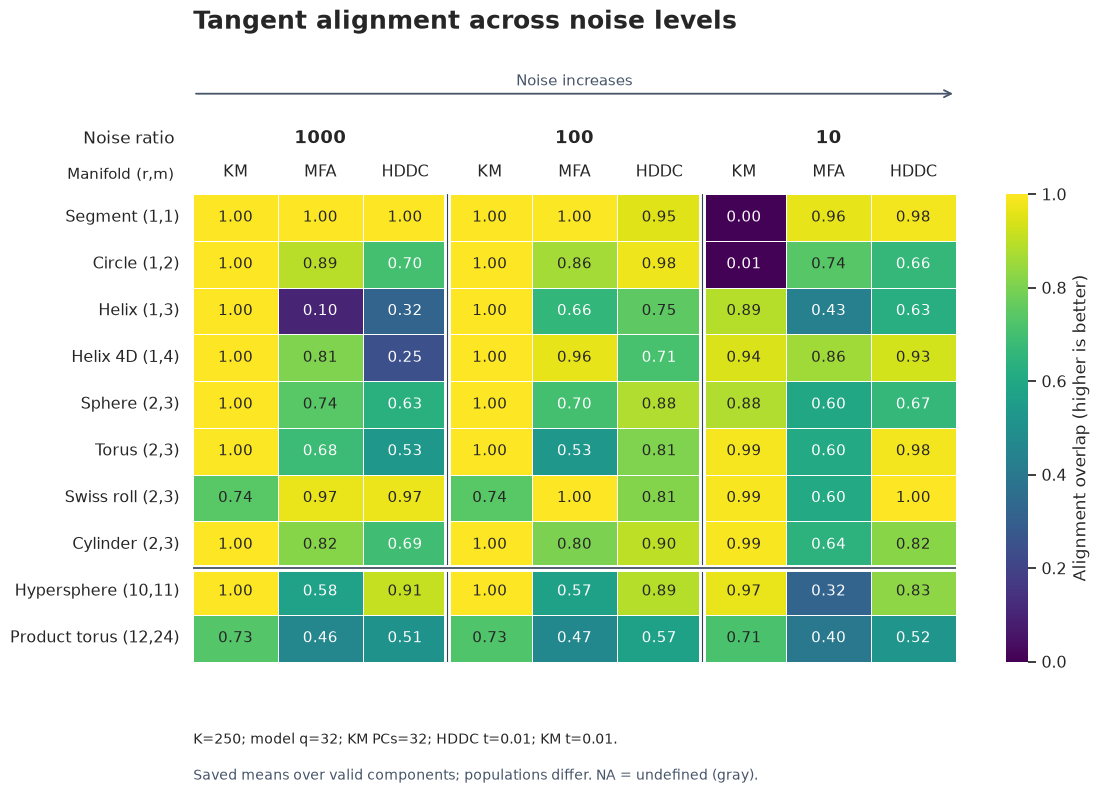

In [34]:
def plot_tangent_heatmap(grid, metric_name, filename):
    """Draw either tangent-overlap metric with the shared heatmap layout."""
    sns.set_theme(style="white", context="notebook", font_scale=1.05)
    fig, ax = plt.subplots(figsize=(12.5, 8.2))
    fig.subplots_adjust(left=0.24, right=0.85, bottom=0.19, top=0.76)
    cbar_ax = fig.add_axes([0.89, 0.19, 0.018, 0.57])
    missing_color = "#e5e7eb"
    ax.set_facecolor(missing_color)

    sns.heatmap(
        grid, ax=ax, cmap="viridis", vmin=0, vmax=1,
        annot=True, fmt=".2f", annot_kws={"fontsize": 11},
        linewidths=0.6, linecolor="white", mask=grid.isna(),
        xticklabels=grid.columns.get_level_values("model"),
        yticklabels=grid.index, cbar_ax=cbar_ax,
        cbar_kws={"label": f"{metric_name} overlap (higher is better)", "ticks": np.linspace(0, 1, 6)},
    )
    for row, col in np.argwhere(grid.isna().to_numpy()):
        ax.text(col + 0.5, row + 0.5, "NA", ha="center", va="center", color="#475569", fontsize=11)

    ax.xaxis.tick_top()
    ax.tick_params(axis="x", rotation=0, length=0, pad=10)
    ax.tick_params(axis="y", rotation=0, length=0, pad=10)
    ax.set(xlabel="", ylabel="")

    # The upper header groups adjacent KM / MFA / HDDC columns by noise ratio.
    block_width = len(MODEL_LABELS)
    for block, ratio in enumerate(noise_ratios):
        center = block_width * (block + 0.5)
        ax.text(center, 1.10, f"{ratio:g}", transform=ax.get_xaxis_transform(),
                ha="center", va="bottom", fontsize=13, fontweight="bold")
    ax.text(-0.025, 1.10, "Noise ratio", transform=ax.transAxes,
            ha="right", va="bottom", fontsize=12)
    ax.text(-0.025, 1.025, "Manifold (r,m)", transform=ax.transAxes,
            ha="right", va="bottom", fontsize=11)
    ax.annotate("", xy=(1, 1.215), xytext=(0, 1.215), xycoords="axes fraction",
                arrowprops={"arrowstyle": "->", "lw": 1.3, "color": "#475569"})
    ax.text(0.5, 1.225, "Noise increases", transform=ax.transAxes,
            ha="center", va="bottom", fontsize=11, color="#475569")

    # Separate noise blocks and the two high-dimensional manifolds.
    for boundary in range(block_width, len(column_order), block_width):
        ax.axvline(boundary, color="white", linewidth=5)
        ax.axvline(boundary, color="#334155", linewidth=0.8)
    separator = len(catalog) - 2
    ax.axhline(separator, color="white", linewidth=5)
    ax.axhline(separator, color="#334155", linewidth=1.2)

    fig.text(0.24, 0.985, f"Tangent {metric_name.lower()} across noise levels", fontsize=18, fontweight="bold", va="top")
    fig.text(0.24, 0.09, f"K={K}; model q={MODEL_Q_CAPACITY}; KM PCs={KM_PCA_CAPACITY}; HDDC t={HDDC_THRESHOLD:g}; KM t={KM_CATTELL_THRESHOLD:g}.", fontsize=10)
    fig.text(0.24, 0.046, "Saved means over valid components; populations differ. NA = undefined (gray).", fontsize=10, color="#475569")

    PLOT_DIR.mkdir(parents=True, exist_ok=True)
    for suffix in ("png", "pdf"):
        fig.savefig(PLOT_DIR / f"{filename}.{suffix}", dpi=250, bbox_inches="tight", facecolor="white")
    plt.show()

plot_tangent_heatmap(alignment, "Alignment", "alignment_overlap_heatmap")

### Alignment values and component counts

Cells below show **valid / undefined** component counts in the same order as
the heatmap. The source means exclude undefined components, and the eligible
populations differ between KM and the trained models. Counts describe the
reported evaluation population; they are not counts of points or repeated runs.
See the [evaluation contract](../docs/evaluation/toy-manifold-tiling.md#tangent-subspace-geometry).

The figure is exported as PNG and PDF under the database's `plots/` directory.
CSV files retain the full-precision heatmap values and the selected source rows
(including validity counts, evaluation IDs, source paths, and source hashes).

In [35]:
component_counts = valid_counts.astype(str) + " / " + undefined_counts.astype(str)
display(component_counts)

alignment.to_csv(PLOT_DIR / "alignment_overlap_values.csv")
audit_columns = [
    "noise_ratio", "model", "K", "q_capacity", "pca_capacity", "type_name", "intrinsic_dim", "embedding_dim",
    METRIC, VALID, UNDEFINED, "training__surgery_threshold", "cattell_threshold",
    "evaluation_id", "source_path", "source_sha256",
]
# Use the shared manifold catalog for KM's missing native embedding dimensions.
plot_rows["embedding_dim"] = plot_rows["manifold_id"].map(catalog.set_index("manifold_id")["embedding_dim"])
plot_rows["model"] = pd.Categorical(plot_rows["model"], categories=list(MODEL_LABELS.values()), ordered=True)
plot_rows["manifold_id"] = pd.Categorical(plot_rows["manifold_id"], categories=row_ids, ordered=True)
plot_rows.sort_values(["manifold_id", "noise_ratio", "model"], ascending=[True, False, True])[
    audit_columns
].to_csv(PLOT_DIR / "alignment_overlap_source_rows.csv", index=False)
selected[selection_columns].to_csv(PLOT_DIR / "selected_evaluations.csv", index=False)
print(f"Saved figure and tables to {PLOT_DIR.relative_to(REPO)}")

noise_ratio              1000                    100                     10    \
model                      KM     MFA    HDDC      KM     MFA    HDDC      KM   
Manifold (r,m)                                                                  
Segment (1,1)           7 / 0   7 / 0   7 / 0   9 / 0   8 / 0   8 / 0  31 / 0   
Circle (1,2)            9 / 0  12 / 0  12 / 0  11 / 0  12 / 0  12 / 0  35 / 0   
Helix (1,3)            17 / 0  13 / 0  13 / 0  18 / 0  16 / 0  16 / 0  22 / 0   
Helix 4D (1,4)         13 / 0  11 / 6   9 / 8  12 / 0  17 / 0  13 / 4  19 / 0   
Sphere (2,3)           22 / 0  21 / 0  21 / 0  24 / 0  25 / 0  25 / 0  35 / 0   
Torus (2,3)            26 / 0  20 / 0  20 / 0  25 / 0  16 / 0  16 / 0  16 / 0   
Swiss roll (2,3)       11 / 0  11 / 0  11 / 0  11 / 0   9 / 0   5 / 4   5 / 0   
Cylinder (2,3)         20 / 0  19 / 0  19 / 0  18 / 0  23 / 0  23 / 0  22 / 0   
Hypersphere (10,11)    53 / 0  55 / 0  55 / 0  54 / 0  54 / 0  54 / 0  40 / 0   
Product torus (12,24)  72 / 0  75 / 0  75 / 0  68 / 0  70 / 0  70 / 0  25 / 0   

noise_ratio                            
model                     MFA    HDDC  
Manifold (r,m)                         
Segment (1,1)          30 / 0  30 / 0  
Circle (1,2)           26 / 0  26 / 0  
Helix (1,3)            29 / 0  29 / 0  
Helix 4D (1,4)         20 / 5  24 / 1  
Sphere (2,3)           36 / 0  36 / 0  
Torus (2,3)            18 / 0  18 / 0  
Swiss roll (2,3)        5 / 0   3 / 2  
Cylinder (2,3)         18 / 0  18 / 0  
Hypersphere (10,11)    41 / 0  41 / 0  
Product torus (12,24)  22 / 0  22 / 0

Saved figure and tables to outputs/experiments/toy_noise_sweep_metrics/plots


## Tangent containment

Plot the saved `tangent_containment__subspace_overlap__mean`, using the same
model settings, row/column order, annotations, separators, and $[0,1]$ color
scale as the alignment heatmap.

Containment compares the exact $r$-dimensional tangent $T$ with the leading
$s$ PCs $P^{(s)}$, where $s$ is the model's learned rank:
$\|{P^{(s)}}^\top T\|_F^2/r$. HDDC uses its saved active rank; MFA uses its
loading-variance rank rule; KM uses its Cattell-selected rank. The HDDC
surgery threshold and KM Cattell threshold come from `HDDC_THRESHOLD` and
`KM_CATTELL_THRESHOLD`, respectively, and are shown in the figure caption.
Containment can improve with larger learned rank because extra directions
are not penalized. The figure uses the saved component means and preserves
undefined values as `NA`.

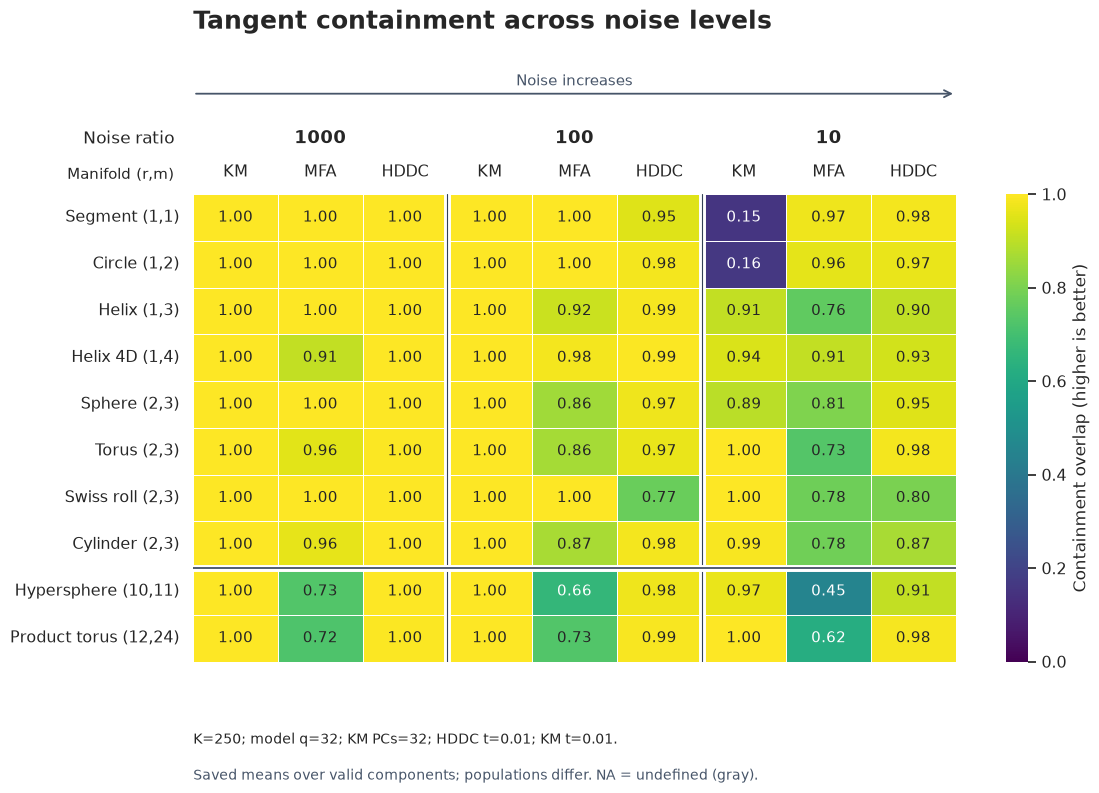

In [36]:
CONTAINMENT_METRIC = "tangent_containment__subspace_overlap__mean"
CONTAINMENT_VALID = "tangent_containment__subspace_overlap__valid_components"
CONTAINMENT_UNDEFINED = "tangent_containment__subspace_overlap__undefined_components"

containment = metric_grid(CONTAINMENT_METRIC).astype(float)
containment_valid_counts = metric_grid(CONTAINMENT_VALID).astype(int)
containment_undefined_counts = metric_grid(CONTAINMENT_UNDEFINED).astype(int)
assert containment.stack(level=[0, 1]).dropna().between(0, 1).all()
assert containment.isna().equals(containment_valid_counts.eq(0))
assert containment.index.equals(alignment.index)
assert containment.columns.equals(alignment.columns)

plot_tangent_heatmap(containment, "Containment", "containment_overlap_heatmap")

### Alignment values and component counts

In [37]:
# Valid / undefined component counts for containment, in heatmap order.
containment_counts = (
    containment_valid_counts.astype(str) + " / " + containment_undefined_counts.astype(str)
)
display(containment_counts)

containment.to_csv(PLOT_DIR / "containment_overlap_values.csv")
containment_audit_columns = [
    "noise_ratio", "model", "K", "q_capacity", "pca_capacity", "type_name", "intrinsic_dim", "embedding_dim",
    CONTAINMENT_METRIC, CONTAINMENT_VALID, CONTAINMENT_UNDEFINED,
    "training__surgery_threshold", "cattell_threshold",
    "evaluation_id", "source_path", "source_sha256",
]
plot_rows.sort_values(["manifold_id", "noise_ratio", "model"], ascending=[True, False, True])[
    containment_audit_columns
].to_csv(PLOT_DIR / "containment_overlap_source_rows.csv", index=False)
print(f"Saved containment figure and tables to {PLOT_DIR.relative_to(REPO)}")

noise_ratio              1000                    100                     10    \
model                      KM     MFA    HDDC      KM     MFA    HDDC      KM   
Manifold (r,m)                                                                  
Segment (1,1)           7 / 0   7 / 0   7 / 0   9 / 0   8 / 0   8 / 0  31 / 0   
Circle (1,2)            9 / 0  12 / 0  12 / 0  11 / 0  12 / 0  12 / 0  35 / 0   
Helix (1,3)            17 / 0  13 / 0  13 / 0  18 / 0  16 / 0  16 / 0  22 / 0   
Helix 4D (1,4)         13 / 0  11 / 6   9 / 8  12 / 0  17 / 0  13 / 4  19 / 0   
Sphere (2,3)           22 / 0  21 / 0  21 / 0  24 / 0  25 / 0  25 / 0  35 / 0   
Torus (2,3)            26 / 0  20 / 0  20 / 0  25 / 0  16 / 0  16 / 0  16 / 0   
Swiss roll (2,3)       11 / 0  11 / 0  11 / 0  11 / 0   9 / 0   9 / 0   5 / 0   
Cylinder (2,3)         20 / 0  19 / 0  19 / 0  18 / 0  23 / 0  23 / 0  22 / 0   
Hypersphere (10,11)    53 / 0  55 / 0  55 / 0  54 / 0  54 / 0  54 / 0  40 / 0   
Product torus (12,24)  72 / 0  75 / 0  75 / 0  68 / 0  70 / 0  70 / 0  25 / 0   

noise_ratio                            
model                     MFA    HDDC  
Manifold (r,m)                         
Segment (1,1)          30 / 0  30 / 0  
Circle (1,2)           26 / 0  26 / 0  
Helix (1,3)            29 / 0  29 / 0  
Helix 4D (1,4)         20 / 5  24 / 1  
Sphere (2,3)           36 / 0  36 / 0  
Torus (2,3)            18 / 0  18 / 0  
Swiss roll (2,3)        5 / 0   5 / 0  
Cylinder (2,3)         18 / 0  18 / 0  
Hypersphere (10,11)    41 / 0  41 / 0  
Product torus (12,24)  22 / 0  22 / 0

Saved containment figure and tables to outputs/experiments/toy_noise_sweep_metrics/plots


# Plots for report

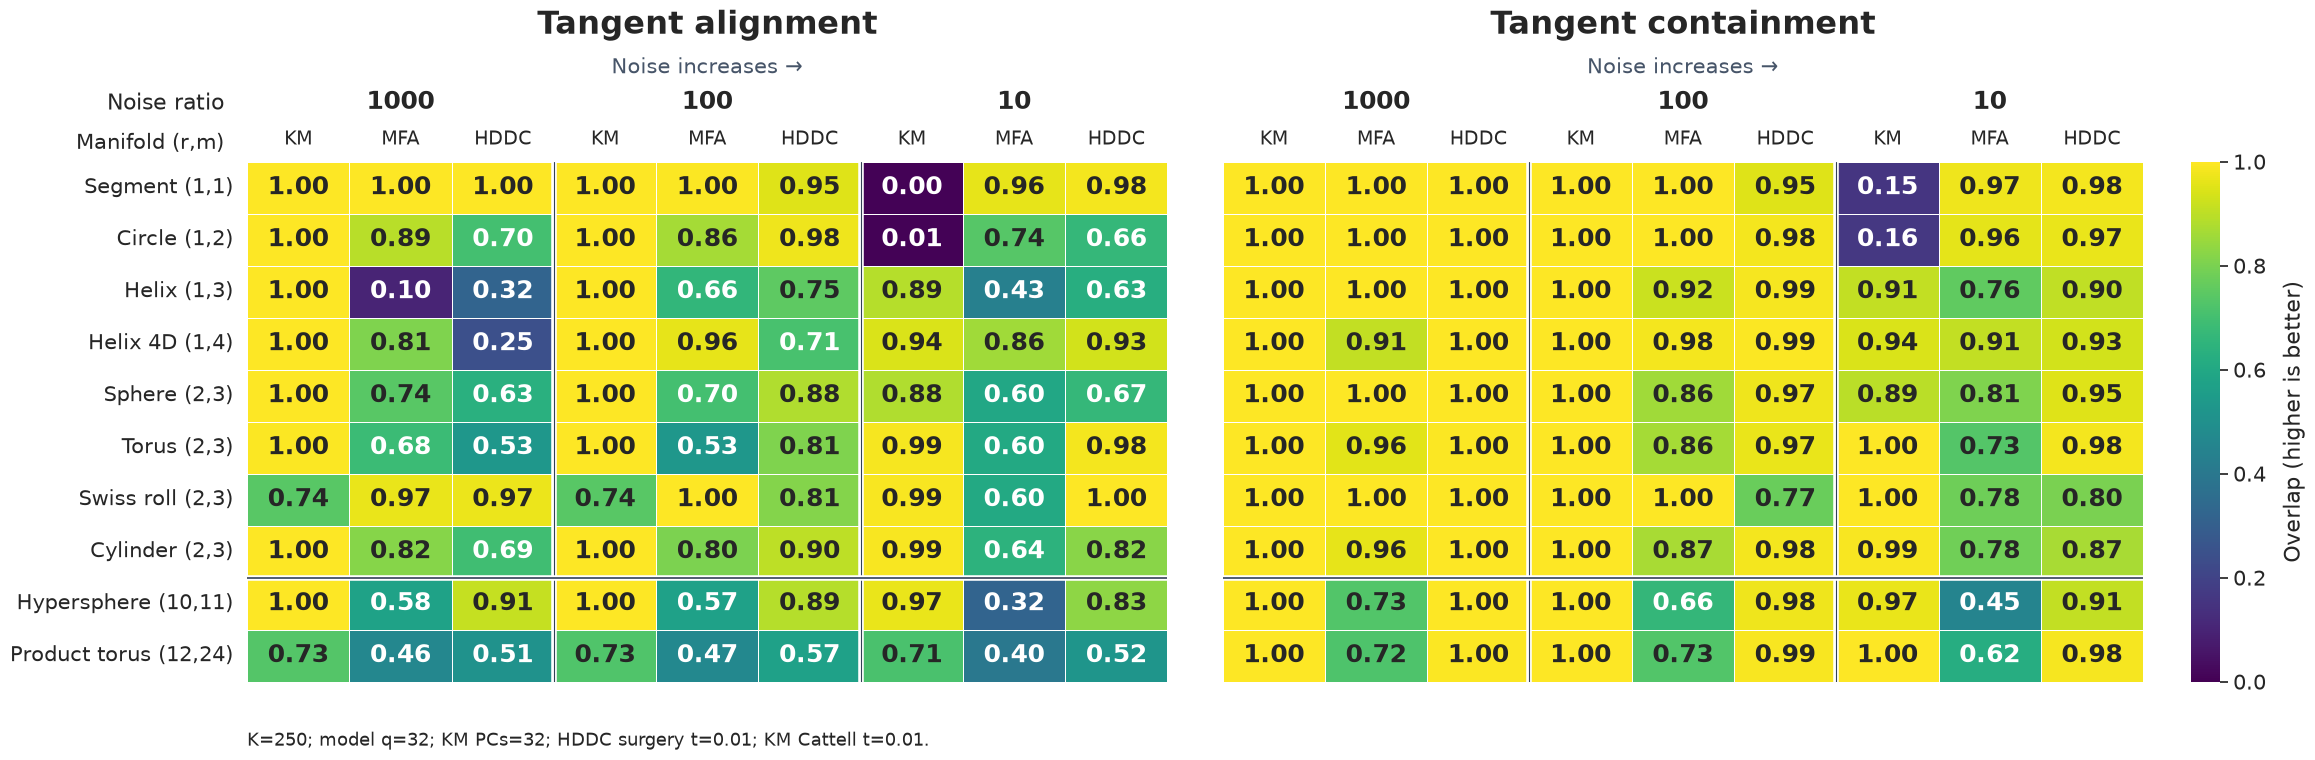

In [38]:
# Report figure: alignment and containment side by side with larger numbers.
fig, axes = plt.subplots(1, 2, figsize=(24, 8), sharey=True)
fig.subplots_adjust(left=0.14, right=0.93, bottom=0.12, top=0.77, wspace=0.06)
cbar_ax = fig.add_axes([0.95, 0.12, 0.012, 0.65])
annotation_size = 18
block_width = len(MODEL_LABELS)

for panel, (ax, grid, title) in enumerate(zip(
    axes, (alignment, containment), ("Tangent alignment", "Tangent containment")
)):
    ax.set_facecolor("#e5e7eb")
    sns.heatmap(
        grid, ax=ax, cmap="viridis", vmin=0, vmax=1,
        annot=True, fmt=".2f", annot_kws={"fontsize": annotation_size, "fontweight": "bold"},
        linewidths=0.6, linecolor="white", mask=grid.isna(),
        xticklabels=grid.columns.get_level_values("model"), yticklabels=grid.index,
        cbar=panel == 1, cbar_ax=cbar_ax if panel == 1 else None,
        cbar_kws={"ticks": np.linspace(0, 1, 6)},
    )
    for row, col in np.argwhere(grid.isna().to_numpy()):
        ax.text(col + 0.5, row + 0.5, "NA", ha="center", va="center",
                color="#475569", fontsize=annotation_size, fontweight="bold")
    ax.set(xlabel="", ylabel="")
    ax.xaxis.tick_top()
    ax.tick_params(axis="x", rotation=0, length=0, pad=9, labelsize=14)
    ax.tick_params(axis="y", rotation=0, length=0, pad=10, labelsize=15, labelleft=panel == 0)
    for block, ratio in enumerate(noise_ratios):
        ax.text(block_width * (block + 0.5), 1.09, f"{ratio:g}",
                transform=ax.get_xaxis_transform(), ha="center", va="bottom",
                fontsize=18, fontweight="bold")
    ax.set_title(title, fontsize=23, fontweight="bold", y=1.23)
    ax.annotate("Noise increases →", xy=(0.5, 1.17), xycoords="axes fraction",
                ha="center", fontsize=15, color="#475569")
    for boundary in range(block_width, len(grid.columns), block_width):
        ax.axvline(boundary, color="white", linewidth=4)
        ax.axvline(boundary, color="#334155", linewidth=0.8)
    ax.axhline(len(catalog) - 2, color="white", linewidth=4)
    ax.axhline(len(catalog) - 2, color="#334155", linewidth=1.2)

axes[0].text(-0.025, 1.09, "Noise ratio", transform=axes[0].transAxes,
             ha="right", va="bottom", fontsize=16)
axes[0].text(-0.025, 1.015, "Manifold (r,m)", transform=axes[0].transAxes,
             ha="right", va="bottom", fontsize=15)
cbar_ax.tick_params(labelsize=15)
cbar_ax.set_ylabel("Overlap (higher is better)", fontsize=16, labelpad=12)
fig.text(0.14, 0.04,
         f"K={K}; model q={MODEL_Q_CAPACITY}; KM PCs={KM_PCA_CAPACITY}; "
         f"HDDC surgery t={HDDC_THRESHOLD:g}; KM Cattell t={KM_CATTELL_THRESHOLD:g}.", fontsize=13)
PLOT_DIR.mkdir(parents=True, exist_ok=True)
for suffix in ("png", "pdf"):
    fig.savefig(PLOT_DIR / f"alignment_containment_heatmaps.{suffix}",
                dpi=300, bbox_inches="tight", facecolor="white")
plt.show()


## Rank recovery and live components

Use one row per model and available noise ratio, in the same three-row blocks
and noise order as the heatmaps. HDDC surgery and KM Cattell thresholds use
the notebook configuration (`HDDC_THRESHOLD` and `KM_CATTELL_THRESHOLD`). Each rank statistic is first computed within each manifold, then
averaged **equally over all ten manifold types**. Both exact-match percentages
are reported: $q_k=r$ (intrinsic dimension) and $q_k=m$ (native embedding
dimension, not $D=128$). The mean rank is context for these exact-match results.

**Rank definitions are model-specific.** Vanilla MFA has configured rank `MODEL_Q_CAPACITY`;
the table uses the evaluator's **post-hoc effective rank**
$\hat q_k=\#\{j:s_{kj}^2>\overline\psi_k\}$ (recorded threshold 1), not the
configured rank. HDDC uses **`hddc_rank_mask_count`** directly, without additional
noise-floor filtering, with capacity `MODEL_Q_CAPACITY`. KM uses **`raw_cattell_scree_rank`**
with capacity `KM_PCA_CAPACITY`, among eligible associated clusters.
The minimum population is read from the selected evaluations (26 points for
the default 16-PC KM reports).
These definitions are preserved in the exported table data.

**Live / total components** reports the saved number of components with at
least one assigned point divided by the model's total component count $K$.
These are whole-run counts, not macro-averages across manifolds.

**NLL (validation)** is the saved overall mean per validation point, lower is
better. Per-manifold NLL is absent from the database, so this column is explicitly
**not a macro-average**. KM has no probabilistic density and reports `—`.

The database omits KM's per-manifold $q_k=m$ accuracy. The cell below derives
only that missing statistic from the existing component-rank sidecars linked by
the database. It checks their populations and recorded intrinsic-rank statistics
against the database and records the sidecar hashes. No models are reevaluated.

In [39]:
import hashlib
import json
import torch

rank_definitions = {
    "kmeans": "raw_cattell_scree_rank",
    "mfa": "loading_variance_above_noise_threshold",
    "hddc": "hddc_rank_mask_count",
}
for model_kind, definition in rank_definitions.items():
    model_rows = selected.loc[selected["model_kind"].eq(model_kind)]
    assert model_rows["rank__definition"].eq(definition).all()
assert selected.loc[selected["model_kind"].eq("mfa"), "rank__threshold"].eq(1).all()
assert selected.loc[selected["model_kind"].eq("hddc"), "rank__threshold"].isna().all()
for model_kind, capacity in {"kmeans": KM_PCA_CAPACITY, "mfa": MODEL_Q_CAPACITY, "hddc": MODEL_Q_CAPACITY}.items():
    assert selected.loc[selected["model_kind"].eq(model_kind), "q_capacity"].eq(capacity).all()
km_min_populations = selected.loc[selected["model_kind"].eq("kmeans"), "eligibility__min_population"].unique()
assert len(km_min_populations) == 1 and pd.notna(km_min_populations[0])
km_min_population = int(km_min_populations[0])

# One instance per type in this benchmark: each type receives weight 1/10.
rank_by_type = plot_rows.copy()
assert not rank_by_type.duplicated(["evaluation_id", "type_name"]).any()
assert rank_by_type.groupby("evaluation_id")["type_name"].nunique().eq(10).all()
rank_by_type["native_match_fraction"] = rank_by_type["ambient_rank__exact_match"].astype(float)
rank_by_type["native_match_source"] = "saved ambient_rank__exact_match"
rank_by_type["rank_sidecar_path"] = ""
rank_by_type["rank_sidecar_sha256"] = ""

for _, run in selected.loc[selected["model_kind"].eq("kmeans")].iterrows():
    report_path = Path(run["source_path"])
    assert hashlib.sha256(report_path.read_bytes()).hexdigest() == run["source_sha256"]
    report = json.loads(report_path.read_text())
    sidecar_path = Path(run["artifacts__component_details_path"])
    details = torch.load(sidecar_path, map_location="cpu", weights_only=True)
    assert details["schema_version"] == 1 and details["K"] == int(run["K"])
    threshold_index = (details["cattell_thresholds"] == KM_CATTELL_THRESHOLD).nonzero().flatten()
    assert threshold_index.numel() == 1
    component_ranks = details["cattell_ranks"][threshold_index.item()]
    sidecar_sha256 = hashlib.sha256(sidecar_path.read_bytes()).hexdigest()
    run_mask = rank_by_type["evaluation_id"].eq(run["evaluation_id"])

    # Sidecar manifold indices refer to the source report's order, not plot order.
    for manifold_index, manifold in enumerate(report["per_manifold"]):
        row_mask = run_mask & rank_by_type["manifold_id"].eq(manifold["manifold_id"])
        assert int(row_mask.sum()) == 1
        row = rank_by_type.loc[row_mask].iloc[0]
        assert row["type_name"] == manifold["type_name"]
        associated = details["associated"] & details["associated_manifold_indices"].eq(manifold_index)
        eligible = associated & details["eligible"]
        q = component_ranks[eligible]
        assert int(associated.sum()) == int(row["components__associated"])
        assert q.numel() == int(row["rank__components"]) > 0
        assert details["target_intrinsic_dims"][eligible].eq(int(row["intrinsic_dim"])).all()
        np.testing.assert_allclose(q.double().mean().item(), float(row["rank__mean_learned"]), rtol=1e-6)
        np.testing.assert_allclose(
            q.eq(int(row["intrinsic_dim"])).double().mean().item(),
            float(row["rank__exact_match"]), rtol=1e-6, atol=1e-8,
        )
        rank_by_type.loc[row_mask, "native_match_fraction"] = q.eq(int(row["embedding_dim"])).double().mean().item()
    rank_by_type.loc[run_mask, "native_match_source"] = "saved component Cattell ranks compared with native m"
    rank_by_type.loc[run_mask, "rank_sidecar_path"] = str(sidecar_path)
    rank_by_type.loc[run_mask, "rank_sidecar_sha256"] = sidecar_sha256

# Rank summaries retain their recorded populations.
assert rank_by_type["rank__components"].gt(0).all()
macro_columns = ["rank__mean_learned", "rank__exact_match", "native_match_fraction"]
assert rank_by_type[macro_columns].notna().all().all(), "Do not silently omit a manifold from a macro-average."
for column in macro_columns[1:]:
    assert rank_by_type[column].between(0, 1).all()

In [40]:
model_names = {"kmeans": "K-means + PCA", "mfa": "Vanilla MFA", "hddc": "MFA-HDDC"}
summary_records = []
for _, run in selected.iterrows():
    per_type = rank_by_type.loc[rank_by_type["evaluation_id"].eq(run["evaluation_id"])]
    assert set(per_type["type_name"]) == set(catalog["type_name"])
    macro = per_type[macro_columns].astype(float).mean(axis=0)
    live = int(run["components__live"])
    total = int(run["K"])
    assert 0 <= live <= total
    assert live + int(run["components__dead"]) == total
    summary_records.append({
        "model": model_names[run["model_kind"]],
        "noise_ratio": run["noise_ratio"],
        "macro_mean_q": macro["rank__mean_learned"],
        "macro_exact_r_pct": 100 * macro["rank__exact_match"],
        "macro_exact_m_pct": 100 * macro["native_match_fraction"],
        "components_live": live,
        "components_total": total,
        "validation_nll": run["nll__validation"],
        "nll_aggregation": "overall validation-point mean; not macro",
        "manifold_types": len(per_type),
        "rank_definition": run["rank__definition"],
        "rank_population": run["rank__population"],
        "rank_threshold": run["rank__threshold"],
        "q_capacity": run["q_capacity"],
        "configured_q": run["q_capacity"] if run["model_kind"] == "mfa" else pd.NA,
        "surgery_threshold": run["training__surgery_threshold"],
        "cattell_threshold": run["cattell_threshold"],
        "evaluation_id": run["evaluation_id"],
        "source_path": run["source_path"],
        "source_sha256": run["source_sha256"],
    })
rank_summary = pd.DataFrame(summary_records)
assert len(rank_summary) == 3 * len(noise_ratios)
assert not rank_summary.duplicated(["model", "noise_ratio"]).any()
assert rank_summary.loc[rank_summary["model"].ne("K-means + PCA"), "validation_nll"].notna().all()

rank_table = rank_summary.rename(columns={
    "model": "Model", "noise_ratio": "Noise ratio", "macro_mean_q": "Mean qₖ",
    "macro_exact_r_pct": "qₖ = r (%)", "macro_exact_m_pct": "qₖ = m (%)",
    "validation_nll": "NLL (validation)",
})[["Model", "Noise ratio", "Mean qₖ", "qₖ = r (%)", "qₖ = m (%)", "NLL (validation)"]].copy()
rank_table["Live / total components"] = [
    f"{live} / {total}" for live, total in zip(
        rank_summary["components_live"], rank_summary["components_total"]
    )
]
rank_table["NLL (validation)"] = pd.to_numeric(rank_table["NLL (validation)"], errors="raise")
caption = (
    "Rank recovery — rank statistics are macro-averages over 10 manifold types; live/total are whole-run counts; NLL is an overall validation mean. "
    f"K={K}; HDDC surgery t={HDDC_THRESHOLD:g}; KM Cattell t={KM_CATTELL_THRESHOLD:g}."
)
rank_table_style = (
    rank_table.style.hide(axis="index").set_uuid("toy_noise_rank_summary")
    .set_caption(caption)
    .format({"Noise ratio": "{:.0f}", "Mean qₖ": "{:.2f}", "qₖ = r (%)": "{:.1f}",
             "qₖ = m (%)": "{:.1f}", "NLL (validation)": "{:.2f}"}, na_rep="—")
    .set_properties(subset=["qₖ = r (%)", "qₖ = m (%)"], **{"font-weight": "bold", "background-color": "#eef4fa"})
    .set_properties(subset=["Model"], **{"text-align": "left"})
    .set_table_styles([
        {"selector": "caption", "props": [("text-align", "left"), ("font-weight", "bold"), ("margin-bottom", "12px")]},
        {"selector": "th, td", "props": [("padding", "9px 14px"), ("white-space", "nowrap")]},
        *[{"selector": f"tbody tr:nth-child({row + 1}) td", "props": [("border-top", "2px solid #64748b")]}
          for row in range(3, len(rank_table), 3)],
    ])
)
display(rank_table_style)
print(f"{len(rank_table)} rows from the {len(noise_ratios)} available noise ratios: " + ", ".join(f"{r:g}" for r in noise_ratios))

Model,Noise ratio,Mean qₖ,qₖ = r (%),qₖ = m (%),NLL (validation),Live / total components
K-means + PCA,1000,5.22,28.2,70.0,—,250 / 250
Vanilla MFA,1000,32.00,0.0,0.0,-586.07,70 / 250
MFA-HDDC,1000,5.63,12.1,94.9,-584.58,24 / 250
K-means + PCA,100,5.20,30.0,70.0,—,250 / 250
Vanilla MFA,100,31.99,0.0,0.0,-420.86,105 / 250
MFA-HDDC,100,5.36,21.0,75.3,-417.50,159 / 250
K-means + PCA,10,12.67,20.6,35.9,—,250 / 250
Vanilla MFA,10,31.98,0.0,0.0,-136.36,239 / 250
MFA-HDDC,10,5.06,28.1,55.3,-134.94,246 / 250


9 rows from the 3 available noise ratios: 1000, 100, 10


In [41]:
# Full-precision macro results and per-manifold inputs remain inspectable.
rank_summary.to_csv(PLOT_DIR / "rank_macro_summary.csv", index=False)
audit_columns = [
    "evaluation_id", "model_kind", "noise_ratio", "K", "q_capacity", "pca_capacity", "type_name", "intrinsic_dim", "embedding_dim",
    "components__associated", "rank__components", *macro_columns,
    "native_match_source", "rank_sidecar_path", "rank_sidecar_sha256", "source_path", "source_sha256",
]
rank_by_type[audit_columns].to_csv(PLOT_DIR / "rank_macro_per_manifold.csv", index=False)

rank_notes = (
    "Rank statistics are equal-weight macro-averages across ten manifold types. "
    f"HDDC surgery threshold is {HDDC_THRESHOLD:g}; KM Cattell threshold is {KM_CATTELL_THRESHOLD:g}. "
    f"qₖ definitions: K-means + PCA uses raw Cattell rank (capacity {KM_PCA_CAPACITY}; eligible associated clusters with at least {km_min_population} points); "
    f"Vanilla MFA uses post-hoc loading-variance-above-noise effective rank (threshold 1; configured q={MODEL_Q_CAPACITY}); "
    f"MFA-HDDC uses the saved rank-mask count directly (capacity {MODEL_Q_CAPACITY}). "
    "r is intrinsic dimension and m is native embedding dimension. "
    "Live / total components gives the whole-run count of components with at least one assigned point over total K; these are not macro-averages. "
    "NLL is the saved overall mean per validation point, lower is better, and is NOT a macro-average; "
    "K-means has no density NLL (—). KM qₖ=m is derived from the recorded component-rank sidecars. "
    f"The selected slice has {len(noise_ratios)} noise ratios ({', '.join(f'{r:g}' for r in noise_ratios)}), giving {len(rank_table)} rows."
)
html = (
    '<!doctype html><html><head><meta charset="utf-8"><title>Toy noise rank summary</title>'
    '<style>body{font-family:system-ui,sans-serif;margin:32px;color:#1e293b}p{max-width:1050px;line-height:1.5}</style>'
    '</head><body>' + rank_table_style.to_html() + '<p>' + rank_notes + '</p></body></html>'
)
(PLOT_DIR / "rank_macro_summary.html").write_text(html)

# Portable Markdown version, without adding a table-rendering dependency.
formatted = rank_table.copy()
for column, precision in [("Noise ratio", 0), ("Mean qₖ", 2), ("qₖ = r (%)", 1), ("qₖ = m (%)", 1), ("NLL (validation)", 2)]:
    formatted[column] = formatted[column].map(lambda value: "—" if pd.isna(value) else f"{value:.{precision}f}")
lines = ["# " + caption, "", "| " + " | ".join(formatted.columns) + " |", "| " + " | ".join(["---"] * len(formatted.columns)) + " |"]
lines.extend("| " + " | ".join(map(str, row)) + " |" for row in formatted.itertuples(index=False, name=None))
(PLOT_DIR / "rank_macro_summary.md").write_text("\n".join(lines) + "\n\n" + rank_notes + "\n")
print(f"Saved macro table (CSV, HTML, Markdown) and per-manifold inputs to {PLOT_DIR.relative_to(REPO)}")

Saved macro table (CSV, HTML, Markdown) and per-manifold inputs to outputs/experiments/toy_noise_sweep_metrics/plots


## MFA-HDDC surgery threshold sweep at noise ratio 10

Repeat the rank-recovery table for **MFA-HDDC only**, fixing **noise ratio 10**
and retaining the notebook's `K` and `MODEL_Q_CAPACITY` (defaults: 1000 and 32).
Use every remaining surgery threshold in ascending order after the initial
`surgery_threshold=1` exclusion;
`HDDC_THRESHOLD` does not restrict this sweep. Each threshold must identify one
saved evaluation at these settings.

As above, mean rank and the exact-match percentages $q_k=r$ and $q_k=m$ are
**equal-weight macro-averages over all ten manifold types**. HDDC rank is the
saved `hddc_rank_mask_count`. Live / total components and validation NLL are
whole-run statistics. All values come from the loaded metrics database.

In [42]:
HDDC_SWEEP_NOISE_RATIO = 10
hddc_sweep = overall.loc[
    overall["model_kind"].eq("hddc")
    & overall["noise_ratio"].eq(HDDC_SWEEP_NOISE_RATIO)
    & overall["K"].eq(K)
    & overall["q_capacity"].eq(MODEL_Q_CAPACITY)
].sort_values("surgery_threshold").copy()
assert not hddc_sweep.empty, "No MFA-HDDC evaluations match the requested noise ratio, K and capacity."
assert hddc_sweep["surgery_threshold"].notna().all()
assert hddc_sweep["surgery_threshold"].is_unique, (
    "Each surgery threshold needs exactly one evaluation; add run filters for duplicate settings."
)
assert hddc_sweep[["seed", "split_seed", "dataset_seed"]].nunique(dropna=False).eq(1).all()
assert hddc_sweep["rank__definition"].eq("hddc_rank_mask_count").all()
assert hddc_sweep["rank__threshold"].isna().all()
assert hddc_sweep["surgery_threshold"].eq(hddc_sweep["training__surgery_threshold"]).all()

hddc_sweep_by_type = manifolds.loc[
    manifolds["evaluation_id"].isin(hddc_sweep["evaluation_id"])
].copy()
assert not hddc_sweep_by_type.duplicated(["evaluation_id", "type_name"]).any()
for evaluation_id in hddc_sweep["evaluation_id"]:
    per_type = hddc_sweep_by_type.loc[hddc_sweep_by_type["evaluation_id"].eq(evaluation_id)]
    assert len(per_type) == 10 and set(per_type["type_name"]) == set(catalog["type_name"])
hddc_sweep_rank_columns = ["rank__mean_learned", "rank__exact_match", "ambient_rank__exact_match"]
assert hddc_sweep_by_type["rank__components"].gt(0).all()
assert hddc_sweep_by_type["rank__components"].eq(hddc_sweep_by_type["ambient_rank__components"]).all()
assert hddc_sweep_by_type[hddc_sweep_rank_columns].notna().all().all(), (
    "Do not silently omit a manifold from a macro-average."
)
for column in hddc_sweep_rank_columns[1:]:
    assert hddc_sweep_by_type[column].between(0, 1).all()

hddc_sweep_macro = hddc_sweep_by_type.groupby("evaluation_id").agg(
    macro_mean_q=("rank__mean_learned", "mean"),
    macro_exact_r_pct=("rank__exact_match", "mean"),
    macro_exact_m_pct=("ambient_rank__exact_match", "mean"),
)
hddc_sweep_macro[["macro_exact_r_pct", "macro_exact_m_pct"]] *= 100
hddc_sweep_summary = hddc_sweep.merge(
    hddc_sweep_macro, left_on="evaluation_id", right_index=True, validate="one_to_one"
).sort_values("surgery_threshold").reset_index(drop=True)
assert len(hddc_sweep_summary) == len(hddc_sweep)
assert hddc_sweep_summary["nll__validation"].notna().all()
assert hddc_sweep_summary["components__live"].between(0, K).all()
assert (hddc_sweep_summary["components__live"] + hddc_sweep_summary["components__dead"]).eq(K).all()

In [43]:
hddc_sweep_table = hddc_sweep_summary.rename(columns={
    "surgery_threshold": "Surgery threshold", "macro_mean_q": "Mean qₖ",
    "macro_exact_r_pct": "qₖ = r (%)", "macro_exact_m_pct": "qₖ = m (%)",
    "nll__validation": "NLL (validation)",
})[["Surgery threshold", "Mean qₖ", "qₖ = r (%)", "qₖ = m (%)", "NLL (validation)"]].copy()
hddc_sweep_table.insert(0, "Model", "MFA-HDDC")
hddc_sweep_table["Live / total components"] = [
    f"{int(live)} / {int(total)}" for live, total in zip(
        hddc_sweep_summary["components__live"], hddc_sweep_summary["K"]
    )
]
hddc_sweep_caption = (
    f"MFA-HDDC surgery threshold sweep — noise ratio={HDDC_SWEEP_NOISE_RATIO:g}; "
    f"K={K}; rank capacity={MODEL_Q_CAPACITY}. "
    "Rank statistics are macro-averages over 10 manifold types; "
    "live/total are whole-run counts; NLL is an overall validation mean."
)
hddc_sweep_table_style = (
    hddc_sweep_table.style.hide(axis="index").set_uuid("toy_noise_hddc_threshold_summary")
    .set_caption(hddc_sweep_caption)
    .format({"Surgery threshold": "{:g}", "Mean qₖ": "{:.2f}", "qₖ = r (%)": "{:.1f}",
             "qₖ = m (%)": "{:.1f}", "NLL (validation)": "{:.2f}"}, na_rep="—")
    .set_properties(subset=["qₖ = r (%)", "qₖ = m (%)"], **{"font-weight": "bold", "background-color": "#eef4fa"})
    .set_properties(subset=["Model"], **{"text-align": "left"})
    .set_table_styles([
        {"selector": "caption", "props": [("text-align", "left"), ("font-weight", "bold"), ("margin-bottom", "12px")]},
        {"selector": "th, td", "props": [("padding", "9px 14px"), ("white-space", "nowrap")]},
    ])
)
display(hddc_sweep_table_style)
print(f"{len(hddc_sweep_table)} surgery thresholds: " + ", ".join(
    f"{threshold:g}" for threshold in hddc_sweep_summary["surgery_threshold"]
))

Model,Surgery threshold,Mean qₖ,qₖ = r (%),qₖ = m (%),NLL (validation),Live / total components
MFA-HDDC,0.00025,20.01,0.0,40.0,-136.02,220 / 250
MFA-HDDC,0.005,6.52,36.7,35.1,-135.07,250 / 250
MFA-HDDC,0.01,5.06,28.1,55.3,-134.94,246 / 250
MFA-HDDC,0.05,4.48,32.7,47.9,-134.97,249 / 250
MFA-HDDC,0.1,3.57,30.2,47.9,-134.96,250 / 250
MFA-HDDC,0.15,3.28,27.2,47.4,-134.94,250 / 250
MFA-HDDC,0.2,2.80,27.5,47.3,-134.84,250 / 250
MFA-HDDC,0.5,4.21,34.4,45.6,-134.86,250 / 250


8 surgery thresholds: 0.00025, 0.005, 0.01, 0.05, 0.1, 0.15, 0.2, 0.5


## MFA-HDDC: K × surgery threshold at noise ratio 10

Compare every available **K** (rows) and **surgery threshold** (columns), both
in ascending order, with **noise ratio 10** and **rank capacity 32** fixed.
Runs with `surgery_threshold=1` are filtered out in the data-loading cell.
This selection is independent of the single-K table above.

The upper panels show the exact-match percentages **$q_k=r$** (intrinsic
dimension) and **$q_k=m$** (native embedding dimension); the lower panels show
**mean tangent alignment** and **mean tangent containment**. Each score is an
**equal-weight average over all ten manifold types**, using the saved
per-manifold means. HDDC ranks are the saved `hddc_rank_mask_count`.

Gray **NA** means either no saved run or an undefined ten-type average: if
any manifold lacks a metric, that run's average remains undefined. The filtered
selection has 32 runs filling a 4×8 grid. Alignment has 14 numeric cells and
18 NA cells; each other panel has 32 numeric cells and no NA. Undefined means are never dropped from an average.

**Why alignment is undefined:** the evaluator requires a uniquely identifiable
leading $r$-dimensional covariance subspace. In all 18 selected runs with an
undefined macro alignment, the Swiss roll ($r=2$) has mean learned rank 1 and
zero valid alignment components. Its second covariance direction lies in the
tied isotropic-noise eigenspace, so there is no unique leading 2D plane. The
missing Swiss-roll mean propagates to the ten-type average. Containment uses
the learned 1D subspace instead and remains defined (about 0.5 for the Swiss
roll). See the [eigenspace-identifiability contract](../docs/evaluation/toy-manifold-tiling.md#eigenspace-identifiability).

Rank percentages use a fixed 0–100 color scale; tangent scores use 0–1.
The combined PNG/PDF figure and four full-precision CSV grids are saved under
`PLOT_DIR`, with filenames beginning `hddc_noise10_q32_k_threshold`.

In [44]:
HDDC_GRID_NOISE_RATIO = 10
HDDC_GRID_Q_CAPACITY = 32
hddc_grid_runs = overall.loc[
    overall["model_kind"].eq("hddc")
    & overall["noise_ratio"].eq(HDDC_GRID_NOISE_RATIO)
    & overall["q_capacity"].eq(HDDC_GRID_Q_CAPACITY)
].sort_values(["K", "surgery_threshold"]).copy()
assert not hddc_grid_runs.empty, "No MFA-HDDC runs match the heatmap configuration."
assert hddc_grid_runs[["K", "surgery_threshold"]].notna().all().all()
assert not hddc_grid_runs.duplicated(["K", "surgery_threshold"]).any(), (
    "Each K/threshold pair needs exactly one evaluation; add run filters for duplicate settings."
)
assert hddc_grid_runs[["seed", "split_seed", "dataset_seed"]].nunique(dropna=False).eq(1).all()
assert hddc_grid_runs["rank__definition"].eq("hddc_rank_mask_count").all()
assert hddc_grid_runs["rank__threshold"].isna().all()

hddc_grid_by_type = manifolds.loc[
    manifolds["evaluation_id"].isin(hddc_grid_runs["evaluation_id"])
].copy()
assert not hddc_grid_by_type.duplicated(["evaluation_id", "type_name"]).any()
for evaluation_id in hddc_grid_runs["evaluation_id"]:
    per_type = hddc_grid_by_type.loc[hddc_grid_by_type["evaluation_id"].eq(evaluation_id)]
    assert len(per_type) == 10 and set(per_type["type_name"]) == set(catalog["type_name"])

# Source column, panel title, scale (also color maximum), annotation format.
hddc_grid_metrics = {
    "exact_r_pct": ("rank__exact_match", "$q_k=r$ (%)", 100, ".1f"),
    "exact_m_pct": ("ambient_rank__exact_match", "$q_k=m$ (%)", 100, ".1f"),
    "alignment": ("tangent_alignment__subspace_overlap__mean", "Mean tangent alignment", 1, ".2f"),
    "containment": ("tangent_containment__subspace_overlap__mean", "Mean tangent containment", 1, ".2f"),
}
hddc_grid_source_columns = [spec[0] for spec in hddc_grid_metrics.values()]
hddc_grid_values = hddc_grid_by_type[hddc_grid_source_columns].astype(float)
for column in hddc_grid_source_columns:
    assert hddc_grid_values[column].dropna().between(0, 1).all()
# Unlike the default groupby mean, skipna=False propagates undefined types.
hddc_grid_macro = hddc_grid_values.groupby(hddc_grid_by_type["evaluation_id"]).agg(
    lambda values: values.mean(skipna=False)
)
hddc_grid_summary = hddc_grid_runs[["evaluation_id", "K", "surgery_threshold"]].merge(
    hddc_grid_macro, left_on="evaluation_id", right_index=True, validate="one_to_one"
)
assert len(hddc_grid_summary) == len(hddc_grid_runs)
hddc_grid_ks = sorted(hddc_grid_runs["K"].unique())
hddc_grid_thresholds = sorted(hddc_grid_runs["surgery_threshold"].unique())
hddc_grid_coverage = (
    hddc_grid_runs.assign(present=1).pivot(index="K", columns="surgery_threshold", values="present")
    .reindex(index=hddc_grid_ks, columns=hddc_grid_thresholds).fillna(0).astype(int)
)
hddc_grids = {}
for name, (column, title, scale, fmt) in hddc_grid_metrics.items():
    grid = hddc_grid_summary.pivot(index="K", columns="surgery_threshold", values=column)
    hddc_grids[name] = grid.reindex(index=hddc_grid_ks, columns=hddc_grid_thresholds).astype(float) * scale

print(f"{len(hddc_grid_runs)} saved runs across {len(hddc_grid_ks)} K values and {len(hddc_grid_thresholds)} surgery thresholds.")
for name, grid in hddc_grids.items():
    print(f"{hddc_grid_metrics[name][1]}: {grid.count().sum()} numeric cells; {grid.isna().sum().sum()} NA cells.")

32 saved runs across 4 K values and 8 surgery thresholds.
$q_k=r$ (%): 32 numeric cells; 0 NA cells.
$q_k=m$ (%): 32 numeric cells; 0 NA cells.
Mean tangent alignment: 14 numeric cells; 18 NA cells.
Mean tangent containment: 32 numeric cells; 0 NA cells.


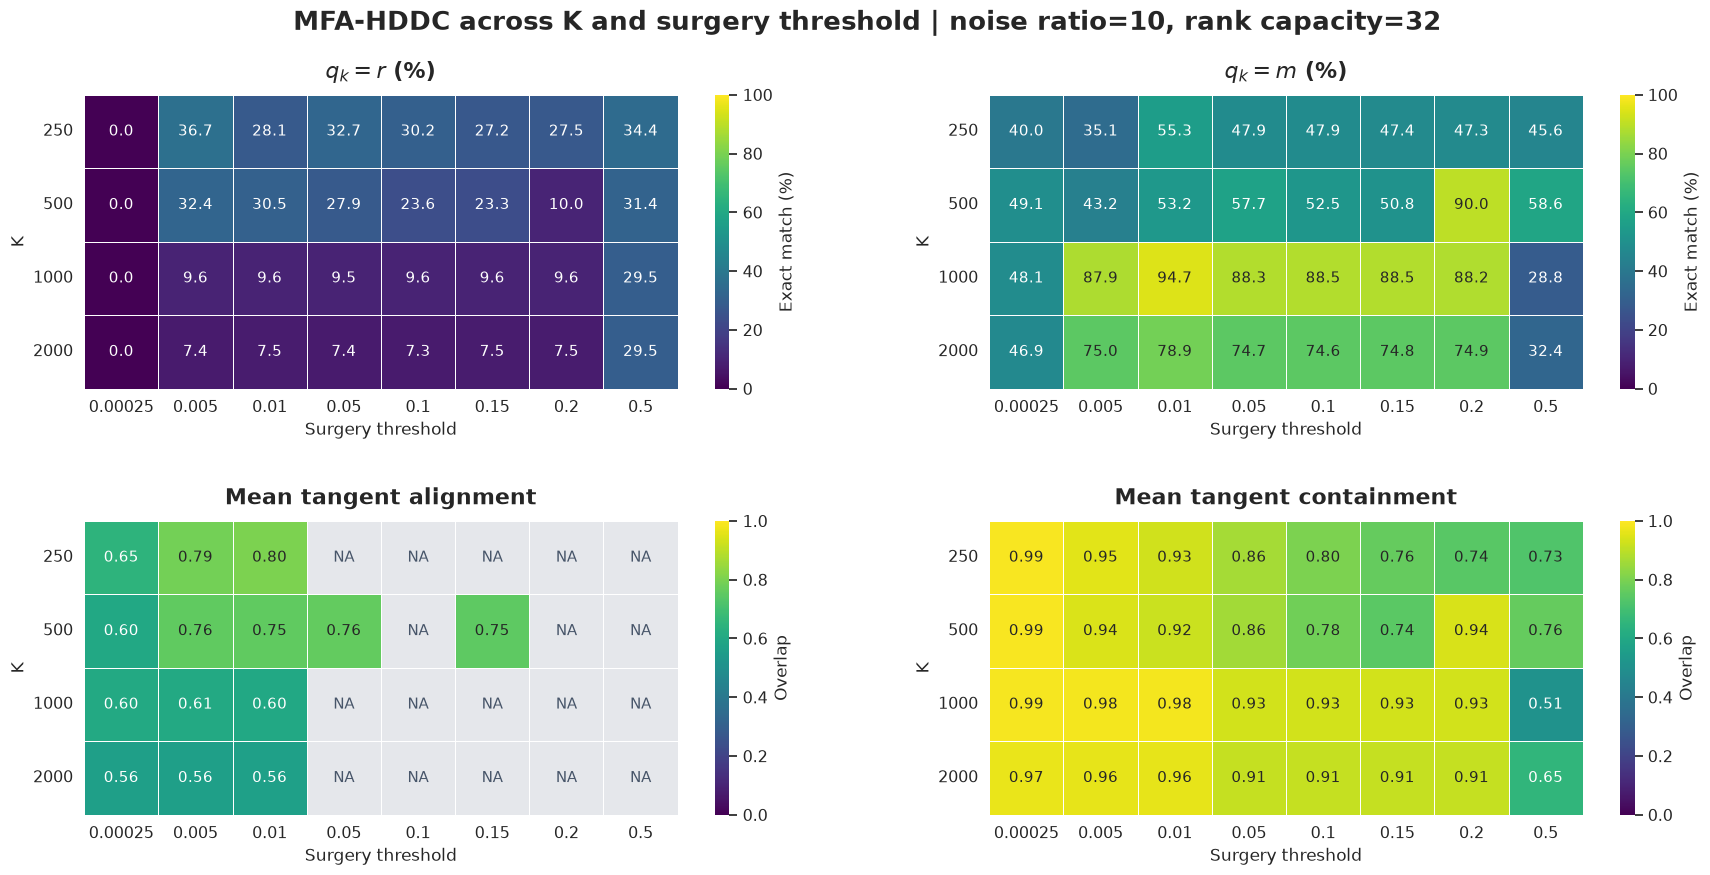

Saved heatmaps (PNG/PDF) and four CSV grids to outputs/experiments/toy_noise_sweep_metrics/plots


In [45]:
sns.set_theme(style="white", context="notebook", font_scale=1.05)
hddc_grid_fig, hddc_grid_axes = plt.subplots(2, 2, figsize=(18, 10))
hddc_grid_fig.subplots_adjust(left=0.065, right=0.98, bottom=0.16, top=0.88, wspace=0.22, hspace=0.45)
for ax, (name, (column, title, scale, fmt)) in zip(hddc_grid_axes.flat, hddc_grid_metrics.items()):
    grid = hddc_grids[name]
    ax.set_facecolor("#e5e7eb")
    sns.heatmap(
        grid, ax=ax, cmap="viridis", vmin=0, vmax=scale,
        annot=True, fmt=fmt, annot_kws={"fontsize": 11},
        linewidths=0.6, linecolor="white", mask=grid.isna(),
        xticklabels=[f"{threshold:g}" for threshold in hddc_grid_thresholds],
        yticklabels=[str(k) for k in hddc_grid_ks],
        cbar_kws={"label": "Exact match (%)" if scale == 100 else "Overlap", "ticks": np.linspace(0, scale, 6)},
    )
    for row, col in np.argwhere(grid.isna().to_numpy()):
        ax.text(col + 0.5, row + 0.5, "NA", ha="center", va="center", color="#475569", fontsize=11)
    ax.set_title(title, fontsize=16, fontweight="bold", pad=12)
    ax.set(xlabel="Surgery threshold", ylabel="K")
    ax.tick_params(axis="both", rotation=0, length=0, pad=8)

hddc_grid_fig.suptitle(
    f"MFA-HDDC across K and surgery threshold | noise ratio={HDDC_GRID_NOISE_RATIO:g}, rank capacity={HDDC_GRID_Q_CAPACITY}",
    fontsize=19, fontweight="bold", y=0.965,
)

PLOT_DIR.mkdir(parents=True, exist_ok=True)
hddc_grid_stem = f"hddc_noise{HDDC_GRID_NOISE_RATIO:g}_q{HDDC_GRID_Q_CAPACITY}_k_threshold"
for suffix in ("png", "pdf"):
    hddc_grid_fig.savefig(PLOT_DIR / f"{hddc_grid_stem}_heatmaps.{suffix}", dpi=250, bbox_inches="tight", facecolor="white")
for name, grid in hddc_grids.items():
    grid.to_csv(PLOT_DIR / f"{hddc_grid_stem}_{name}.csv")
plt.show()
print(f"Saved heatmaps (PNG/PDF) and four CSV grids to {PLOT_DIR.relative_to(REPO)}")

## K-means + PCA: K × Cattell threshold at noise ratio 10

Repeat the four-score heatmaps using **K on rows** and **Cattell threshold on
columns**, both ascending, at **noise ratio 10**. There are four saved K-means
partitions (**K=250, 500, 1000, 2000**, seed 0), each evaluated at nine Cattell
thresholds, yielding **36 evaluations in each 4×9 grid**. These are repeated
rank selections on each fixed partition. Cattell threshold **1 is included**;
the notebook's earlier exclusion applies specifically to HDDC surgery threshold 1.

**The available runs do not hold PCA capacity and scoring eligibility fixed
across K.** The K=1000 run uses capacity 16 and minimum cluster population 26;
the other runs use capacity 32 and minimum population 33. Interpret changes
across K with this difference in mind. Threshold comparisons within each row
share the same partition, PCA basis, and eligible population.

| K | PCA capacity | Minimum cluster population | Eligible, associated clusters |
| ---: | ---: | ---: | ---: |
| 250 | 32 | 33 | 250 |
| 500 | 32 | 33 | 499 |
| 1000 | 16 | 26 | 982 |
| 2000 | 32 | 33 | 1857 |

The upper panels report **$q_k=r$ (%)** and **$q_k=m$ (%)**, where $q_k$ is
the saved raw Cattell rank, $r$ the intrinsic dimension, and $m$ the native
embedding dimension. The lower panels report **mean tangent alignment** and
**mean tangent containment**. Use the recorded per-manifold rank and tangent
scores over eligible, proximity-associated clusters. As in the existing rank
table, derive $q_k=m$ from saved `cattell_ranks` in `component_metrics.pt`,
using the same eligible population and native dimensions from the shared
dataset catalog; the database has no saved `ambient_rank__exact_match` for KM.
No PCA, clustering, or model training is rerun.

Each heatmap cell is an **equal-weight mean over all ten manifold types**.
An undefined per-manifold value propagates to an undefined run average;
undefined values are never silently omitted. Gray **NA** denotes a missing
evaluation or an undefined ten-type average. All four panels currently have
**36 numeric cells and no NA**.

Alignment compares the leading $r$ empirical PCs with the true tangent, so
it is **constant across thresholds within each K row**. Containment uses the
leading $q_k$ PCs and can vary with the Cattell threshold. See the
[K-means geometry definitions](../docs/experiments/kmeans-initialization-evaluation.md#geometry-metrics).

Use the same annotated `viridis` layout as the HDDC figure: rank percentages
on **0–100** scales and tangent overlaps on **0–1** scales, with no figure
footnotes. The combined PNG/PDF figure, four full-precision CSV grids, and
per-manifold inputs with provenance are saved under `PLOT_DIR` with prefix
`kmeans_noise10_k_cattell_threshold`.


In [46]:
import hashlib
import json
import torch

KM_GRID_NOISE_RATIO = 10
km_grid_runs = overall.loc[
    overall["model_kind"].eq("kmeans")
    & overall["noise_ratio"].eq(KM_GRID_NOISE_RATIO)
].sort_values(["K", "cattell_threshold"]).copy()
assert not km_grid_runs.empty, "No K-means + PCA evaluations match the heatmap configuration."
assert km_grid_runs[["K", "cattell_threshold"]].notna().all().all()
assert not km_grid_runs.duplicated(["K", "cattell_threshold"]).any(), (
    "Each K/threshold pair needs exactly one evaluation; add run filters for duplicate settings."
)
assert km_grid_runs.groupby("K")["run_id"].nunique().eq(1).all()
assert km_grid_runs[["seed", "split_seed", "dataset_seed"]].nunique(dropna=False).eq(1).all()
assert km_grid_runs["rank__definition"].eq("raw_cattell_scree_rank").all()
assert km_grid_runs["rank__population"].eq("proximity_associated_and_population_eligible_components").all()
km_grid_by_type = manifolds.loc[
    manifolds["evaluation_id"].isin(km_grid_runs["evaluation_id"])
].copy()
assert not km_grid_by_type.duplicated(["evaluation_id", "type_name"]).any()
assert not km_grid_by_type.duplicated(["evaluation_id", "manifold_id"]).any()
for evaluation_id in km_grid_runs["evaluation_id"]:
    per_type = km_grid_by_type.loc[km_grid_by_type["evaluation_id"].eq(evaluation_id)]
    assert len(per_type) == 10
    assert dict(zip(per_type["manifold_id"], per_type["type_name"])) == dict(zip(catalog["manifold_id"], catalog["type_name"]))

# Reuse the rank table's native-dimension comparison on each saved Cattell rank vector.
km_grid_by_type["embedding_dim"] = km_grid_by_type["manifold_id"].map(catalog.set_index("manifold_id")["embedding_dim"])
km_grid_by_type["native_match_fraction"] = np.nan
km_grid_by_type["native_match_count"] = 0
km_grid_by_type["native_match_source"] = "saved component Cattell ranks compared with native m"
km_grid_by_type["rank_sidecar_sha256"] = ""
for run_id, threshold_runs in km_grid_runs.groupby("run_id", sort=False):
    assert threshold_runs[["source_path", "source_sha256", "artifacts__component_details_path", "pca_capacity", "eligibility__min_population"]].nunique(dropna=False).eq(1).all()
    partition = threshold_runs.iloc[0]
    report_path = Path(partition["source_path"])
    assert hashlib.sha256(report_path.read_bytes()).hexdigest() == partition["source_sha256"]
    report = json.loads(report_path.read_text())
    sidecar_path = Path(partition["artifacts__component_details_path"])
    details = torch.load(sidecar_path, map_location="cpu", weights_only=True)
    assert details["schema_version"] == 1 and details["K"] == int(partition["K"])
    assert details["q_max"] == int(partition["pca_capacity"])
    assert details["min_population"] == int(partition["eligibility__min_population"])
    sidecar_sha256 = hashlib.sha256(sidecar_path.read_bytes()).hexdigest()
    for _, run in threshold_runs.iterrows():
        threshold_index = (details["cattell_thresholds"] == float(run["cattell_threshold"])).nonzero().flatten()
        assert threshold_index.numel() == 1
        component_ranks = details["cattell_ranks"][threshold_index.item()]
        run_mask = km_grid_by_type["evaluation_id"].eq(run["evaluation_id"])
        # Sidecar manifold indices use the source report's order, not plot order.
        for manifold_index, manifold in enumerate(report["per_manifold"]):
            row_mask = run_mask & km_grid_by_type["manifold_id"].eq(manifold["manifold_id"])
            assert int(row_mask.sum()) == 1
            row = km_grid_by_type.loc[row_mask].iloc[0]
            assert row["type_name"] == manifold["type_name"]
            associated = details["associated"] & details["associated_manifold_indices"].eq(manifold_index)
            eligible = associated & details["eligible"]
            q = component_ranks[eligible]
            assert int(associated.sum()) == int(row["components__associated"])
            assert q.numel() == int(row["rank__components"])
            assert details["target_intrinsic_dims"][eligible].eq(int(row["intrinsic_dim"])).all()
            if q.numel():
                assert q.ge(1).all() and q.le(int(run["pca_capacity"])).all()
                np.testing.assert_allclose(q.double().mean().item(), float(row["rank__mean_learned"]), rtol=1e-6)
                np.testing.assert_allclose(
                    q.eq(int(row["intrinsic_dim"])).double().mean().item(),
                    float(row["rank__exact_match"]), rtol=1e-6, atol=1e-8,
                )
                native_matches = int(q.eq(int(row["embedding_dim"])).sum())
                km_grid_by_type.loc[row_mask, "native_match_count"] = native_matches
                km_grid_by_type.loc[row_mask, "native_match_fraction"] = native_matches / q.numel()
        km_grid_by_type.loc[run_mask, "rank_sidecar_sha256"] = sidecar_sha256

# Alignment uses the same intrinsic-dimensional PCA subspace at every threshold.
assert km_grid_by_type.groupby(["run_id", "manifold_id"])[[
    "tangent_alignment__subspace_overlap__mean",
    "tangent_alignment__subspace_overlap__valid_components",
    "tangent_alignment__subspace_overlap__undefined_components",
]].nunique(dropna=False).eq(1).all().all()


In [47]:
# Source column, panel title, scale (also color maximum), annotation format.
km_grid_metrics = {
    "exact_r_pct": ("rank__exact_match", "$q_k=r$ (%)", 100, ".1f"),
    "exact_m_pct": ("native_match_fraction", "$q_k=m$ (%)", 100, ".1f"),
    "alignment": ("tangent_alignment__subspace_overlap__mean", "Mean tangent alignment", 1, ".2f"),
    "containment": ("tangent_containment__subspace_overlap__mean", "Mean tangent containment", 1, ".2f"),
}
km_grid_source_columns = [spec[0] for spec in km_grid_metrics.values()]
km_grid_values = km_grid_by_type[km_grid_source_columns].astype(float)
for column in km_grid_source_columns:
    assert km_grid_values[column].dropna().between(0, 1).all()
# Unlike the default groupby mean, skipna=False propagates undefined types.
km_grid_macro = km_grid_values.groupby(km_grid_by_type["evaluation_id"]).agg(
    lambda values: values.mean(skipna=False)
)
km_grid_summary = km_grid_runs[["evaluation_id", "K", "cattell_threshold"]].merge(
    km_grid_macro, left_on="evaluation_id", right_index=True, validate="one_to_one"
)
assert len(km_grid_summary) == len(km_grid_runs)
km_grid_ks = sorted(km_grid_runs["K"].unique())
km_grid_thresholds = sorted(km_grid_runs["cattell_threshold"].unique())
km_grid_coverage = (
    km_grid_runs.assign(present=1).pivot(index="K", columns="cattell_threshold", values="present")
    .reindex(index=km_grid_ks, columns=km_grid_thresholds).fillna(0).astype(int)
)
km_grids = {}
for name, (column, title, scale, fmt) in km_grid_metrics.items():
    grid = km_grid_summary.pivot(index="K", columns="cattell_threshold", values=column)
    km_grids[name] = grid.reindex(index=km_grid_ks, columns=km_grid_thresholds).astype(float) * scale

print(f"{len(km_grid_runs)} saved evaluations across {len(km_grid_ks)} K values and {len(km_grid_thresholds)} Cattell thresholds.")
for name, grid in km_grids.items():
    print(f"{km_grid_metrics[name][1]}: {grid.count().sum()} numeric cells; {grid.isna().sum().sum()} NA cells.")
km_grid_settings = km_grid_runs[[
    "K", "pca_capacity", "eligibility__min_population", "association__eligible_associated_components",
]].drop_duplicates().set_index("K").sort_index()
display(km_grid_settings.rename(columns={
    "pca_capacity": "PCA capacity", "eligibility__min_population": "Minimum cluster population",
    "association__eligible_associated_components": "Eligible, associated clusters",
}))


36 saved evaluations across 4 K values and 9 Cattell thresholds.
$q_k=r$ (%): 36 numeric cells; 0 NA cells.
$q_k=m$ (%): 36 numeric cells; 0 NA cells.
Mean tangent alignment: 36 numeric cells; 0 NA cells.
Mean tangent containment: 36 numeric cells; 0 NA cells.


,PCA capacity,Minimum cluster population,"Eligible, associated clusters"
K,,,
250,32,33,250
500,32,33,499
1000,16,26,982
2000,32,33,1857


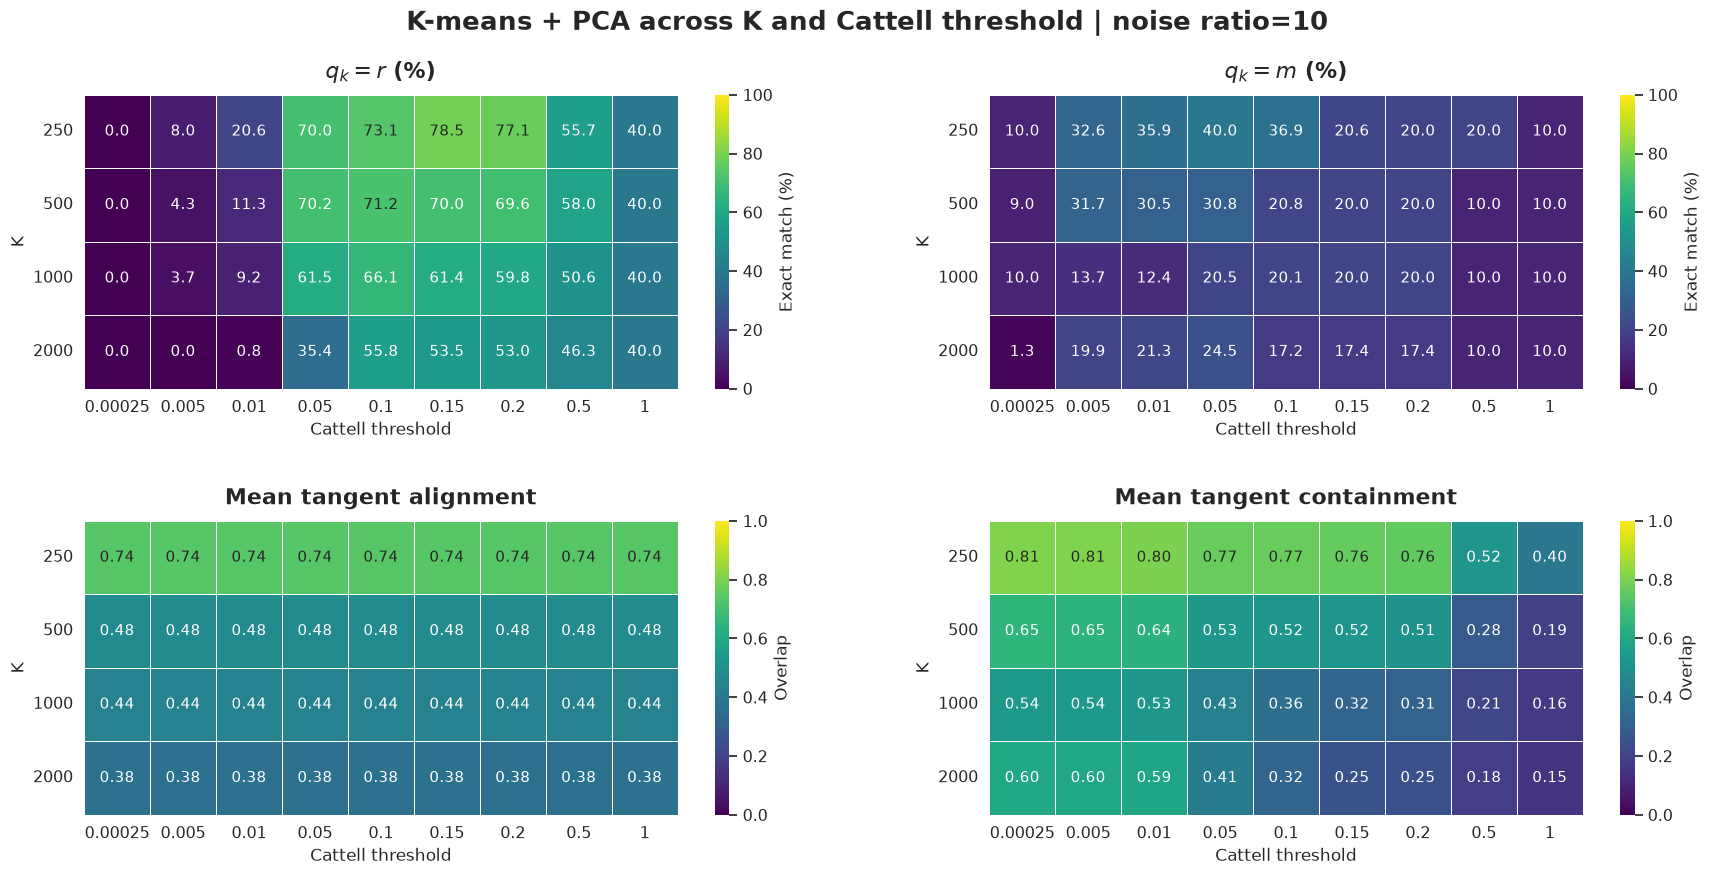

Saved heatmaps (PNG/PDF) and CSV grids/inputs to outputs/experiments/toy_noise_sweep_metrics/plots


In [48]:
sns.set_theme(style="white", context="notebook", font_scale=1.05)
km_grid_fig, km_grid_axes = plt.subplots(2, 2, figsize=(18, 10))
km_grid_fig.subplots_adjust(left=0.065, right=0.98, bottom=0.16, top=0.88, wspace=0.22, hspace=0.45)
for ax, (name, (column, title, scale, fmt)) in zip(km_grid_axes.flat, km_grid_metrics.items()):
    grid = km_grids[name]
    ax.set_facecolor("#e5e7eb")
    sns.heatmap(
        grid, ax=ax, cmap="viridis", vmin=0, vmax=scale,
        annot=True, fmt=fmt, annot_kws={"fontsize": 11},
        linewidths=0.6, linecolor="white", mask=grid.isna(),
        xticklabels=[f"{threshold:g}" for threshold in km_grid_thresholds],
        yticklabels=[str(k) for k in km_grid_ks],
        cbar_kws={"label": "Exact match (%)" if scale == 100 else "Overlap", "ticks": np.linspace(0, scale, 6)},
    )
    for row, col in np.argwhere(grid.isna().to_numpy()):
        ax.text(col + 0.5, row + 0.5, "NA", ha="center", va="center", color="#475569", fontsize=11)
    ax.set_title(title, fontsize=16, fontweight="bold", pad=12)
    ax.set(xlabel="Cattell threshold", ylabel="K")
    ax.tick_params(axis="both", rotation=0, length=0, pad=8)

km_grid_fig.suptitle(
    f"K-means + PCA across K and Cattell threshold | noise ratio={KM_GRID_NOISE_RATIO:g}",
    fontsize=19, fontweight="bold", y=0.965,
)

PLOT_DIR.mkdir(parents=True, exist_ok=True)
km_grid_stem = f"kmeans_noise{KM_GRID_NOISE_RATIO:g}_k_cattell_threshold"
for suffix in ("png", "pdf"):
    km_grid_fig.savefig(PLOT_DIR / f"{km_grid_stem}_heatmaps.{suffix}", dpi=250, bbox_inches="tight", facecolor="white")
for name, grid in km_grids.items():
    grid.to_csv(PLOT_DIR / f"{km_grid_stem}_{name}.csv")
km_grid_by_type[[
    "evaluation_id", "run_id", "model_kind", "noise_ratio", "K", "cattell_threshold", "pca_capacity",
    "seed", "dataset_seed", "manifold_id", "type_name", "intrinsic_dim", "embedding_dim",
    "rank__components", "components__associated", "components__eligible_associated",
    *km_grid_source_columns, "native_match_count", "native_match_source",
    "source_path", "source_sha256", "artifacts__component_details_path", "rank_sidecar_sha256",
]].sort_values(["K", "cattell_threshold", "manifold_id"]).to_csv(
    PLOT_DIR / f"{km_grid_stem}_per_manifold.csv", index=False,
)
km_grid_settings.to_csv(PLOT_DIR / f"{km_grid_stem}_settings.csv")
plt.show()
print(f"Saved heatmaps (PNG/PDF) and CSV grids/inputs to {PLOT_DIR.relative_to(REPO)}")

## Vanilla MFA across K at noise ratio 10

The database contains one vanilla MFA evaluation at each **K=250, 500, 1000,
2000**, with **noise ratio 10**, **configured rank 32**, and training seed 42.
Four line plots with point markers show the two exact-rank match percentages,
mean tangent alignment, and mean tangent containment. The K axis uses base-2
log spacing, so each doubling of K has the same spacing.

Each point is an **equal-weight average across all ten manifold types**.
As in the HDDC plots, any undefined manifold mean makes the corresponding
run average undefined; all four scores are defined for these four MFA runs.

For vanilla MFA, $q_k$ is the evaluator's **post-hoc effective rank**:
the count of loading variances above the mean diagonal noise (recorded
`rank__threshold=1`). It is distinct from the configured rank 32. The two rank
panels show $q_k=r$ and $q_k=m$ percentages, with $r$ the intrinsic dimension
and $m$ the native embedding dimension. Containment uses that effective rank.

The rank-match percentages are all below 0.5%, so both rank panels use a
**zoomed 0–0.5% axis** with explicit percentage labels and point values.
Both tangent panels use the full **0–1** scale. The figure has no footnotes;
PNG/PDF exports, a full-precision summary CSV, and the per-manifold input CSV
are saved under `PLOT_DIR` with prefix `mfa_noise10_q32_k_sweep`.

In [49]:
MFA_K_NOISE_RATIO = 10
MFA_K_Q_CAPACITY = 32
mfa_k_runs = overall.loc[
    overall["model_kind"].eq("mfa")
    & overall["noise_ratio"].eq(MFA_K_NOISE_RATIO)
    & overall["q_capacity"].eq(MFA_K_Q_CAPACITY)
].sort_values("K").copy()
assert len(mfa_k_runs) >= 2, "A K trend needs at least two vanilla MFA evaluations."
assert mfa_k_runs["K"].notna().all() and mfa_k_runs["K"].is_unique, (
    "Each K needs exactly one evaluation; add run filters for duplicate settings."
)
assert mfa_k_runs[["seed", "split_seed", "dataset_seed"]].nunique(dropna=False).eq(1).all()
assert mfa_k_runs["rank__definition"].eq("loading_variance_above_noise_threshold").all()
assert mfa_k_runs["rank__threshold"].eq(1).all()
mfa_k_by_type = manifolds.loc[
    manifolds["evaluation_id"].isin(mfa_k_runs["evaluation_id"])
].copy()
assert not mfa_k_by_type.duplicated(["evaluation_id", "type_name"]).any()
for evaluation_id in mfa_k_runs["evaluation_id"]:
    per_type = mfa_k_by_type.loc[mfa_k_by_type["evaluation_id"].eq(evaluation_id)]
    assert len(per_type) == 10 and set(per_type["type_name"]) == set(catalog["type_name"])

# Source column, panel title, percentage conversion, point-label format.
mfa_k_metrics = {
    "exact_r_pct": ("rank__exact_match", "$q_k=r$", 100, ".3f"),
    "exact_m_pct": ("ambient_rank__exact_match", "$q_k=m$", 100, ".3f"),
    "alignment": ("tangent_alignment__subspace_overlap__mean", "Mean tangent alignment", 1, ".3f"),
    "containment": ("tangent_containment__subspace_overlap__mean", "Mean tangent containment", 1, ".3f"),
}
mfa_k_source_columns = [spec[0] for spec in mfa_k_metrics.values()]
mfa_k_values = mfa_k_by_type[mfa_k_source_columns].astype(float)
for column in mfa_k_source_columns:
    assert mfa_k_values[column].dropna().between(0, 1).all()
mfa_k_macro = mfa_k_values.groupby(mfa_k_by_type["evaluation_id"]).agg(
    lambda values: values.mean(skipna=False)
).rename(columns={spec[0]:name for name, spec in mfa_k_metrics.items()})
for name, (_, _, scale, _) in mfa_k_metrics.items():
    mfa_k_macro[name] *= scale
mfa_k_run_columns = [
    "evaluation_id", "K", "noise_ratio", "q_capacity", "seed", "split_seed", "dataset_seed",
    "rank__definition", "rank__threshold", "source_path", "source_sha256",
]
mfa_k_summary = mfa_k_runs[mfa_k_run_columns].merge(
    mfa_k_macro, left_on="evaluation_id", right_index=True, validate="one_to_one"
).sort_values("K").reset_index(drop=True)
assert len(mfa_k_summary) == len(mfa_k_runs)
print("Vanilla MFA K values: " + ", ".join(str(k) for k in mfa_k_summary["K"]))
print("Defined ten-type means per score:")
print(mfa_k_summary[list(mfa_k_metrics)].count().to_string())

Vanilla MFA K values: 250, 500, 1000, 2000
Defined ten-type means per score:
exact_r_pct    4
exact_m_pct    4
alignment      4
containment    4


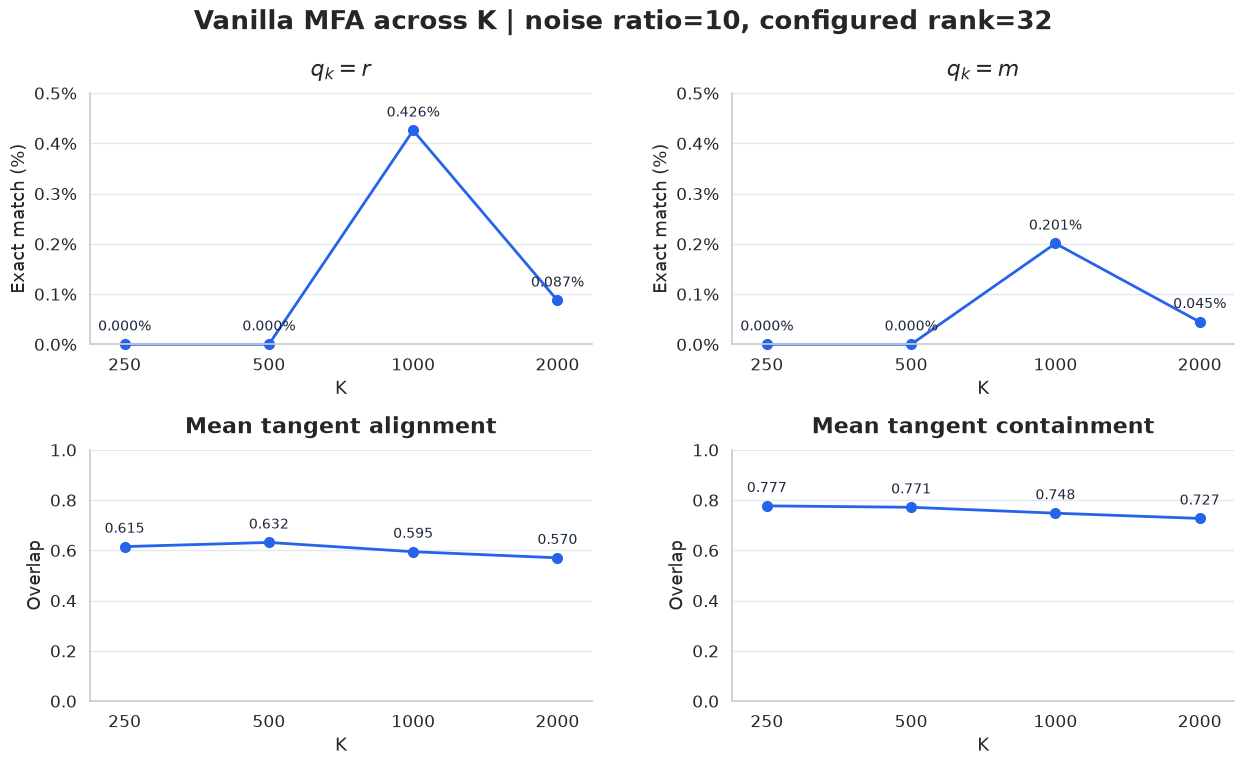

Saved vanilla MFA K-sweep figure and CSV tables to outputs/experiments/toy_noise_sweep_metrics/plots


In [50]:
from matplotlib.ticker import PercentFormatter, ScalarFormatter

MFA_K_RANK_YMAX = 0.5  # Percentage points: show the small exact-match rates clearly.
assert mfa_k_summary[["exact_r_pct", "exact_m_pct"]].max().max() <= MFA_K_RANK_YMAX
sns.set_theme(style="whitegrid", context="notebook", font_scale=1.1)
mfa_k_fig, mfa_k_axes = plt.subplots(2, 2, figsize=(13, 8), sharex=True)
mfa_k_fig.subplots_adjust(left=0.09, right=0.97, bottom=0.10, top=0.86, hspace=0.42, wspace=0.28)
for ax, (name, (_, title, scale, fmt)) in zip(mfa_k_axes.flat, mfa_k_metrics.items()):
    scores = mfa_k_summary[name].to_numpy(dtype=float)
    ks = mfa_k_summary["K"].to_numpy(dtype=int)
    ax.plot(ks, scores, marker="o", markersize=7, linewidth=2, color="#2563eb", clip_on=False)
    ax.set_xscale("log", base=2)
    ax.set_xticks(ks)
    ax.xaxis.set_major_formatter(ScalarFormatter())
    ax.set_xlim(ks.min() / 1.18, ks.max() * 1.18)
    ax.set_title(title, fontsize=16, fontweight="bold", pad=12)
    ax.set_xlabel("K")
    if scale == 100:
        ax.set_ylim(0, MFA_K_RANK_YMAX)
        ax.set_ylabel("Exact match (%)")
        ax.yaxis.set_major_formatter(PercentFormatter(xmax=100, decimals=1))
    else:
        ax.set_ylim(0, 1)
        ax.set_ylabel("Overlap")
    ax.tick_params(axis="x", labelbottom=True)
    ax.grid(axis="y", color="#e2e8f0")
    ax.grid(axis="x", visible=False)
    for k, score in zip(ks, scores):
        if np.isfinite(score):
            label = format(score, fmt) + ("%" if scale == 100 else "")
            ax.annotate(label, (k, score), xytext=(0, 10), textcoords="offset points",
                        ha="center", fontsize=10, color="#1e293b")
        else:
            ax.text(k, 0.04, "NA", transform=ax.get_xaxis_transform(), ha="center", color="#475569")
sns.despine(fig=mfa_k_fig)
mfa_k_fig.suptitle(
    f"Vanilla MFA across K | noise ratio={MFA_K_NOISE_RATIO:g}, configured rank={MFA_K_Q_CAPACITY}",
    fontsize=19, fontweight="bold", y=0.965,
)

PLOT_DIR.mkdir(parents=True, exist_ok=True)
mfa_k_stem = f"mfa_noise{MFA_K_NOISE_RATIO:g}_q{MFA_K_Q_CAPACITY}_k_sweep"
for suffix in ("png", "pdf"):
    mfa_k_fig.savefig(PLOT_DIR / f"{mfa_k_stem}.{suffix}", dpi=250, bbox_inches="tight", facecolor="white")
mfa_k_summary.to_csv(PLOT_DIR / f"{mfa_k_stem}_summary.csv", index=False)
mfa_k_by_type[[
    "evaluation_id", "K", "noise_ratio", "q_capacity", "type_name", "intrinsic_dim", "embedding_dim",
    *mfa_k_source_columns, "source_path", "source_sha256",
]].sort_values(["K", "type_name"]).to_csv(PLOT_DIR / f"{mfa_k_stem}_per_manifold.csv", index=False)
plt.show()
print(f"Saved vanilla MFA K-sweep figure and CSV tables to {PLOT_DIR.relative_to(REPO)}")

## MFA-HDDC: Gaussian components across manifolds

For **noise ratio 10**, **surgery threshold 0.1**, and **rank capacity 32**,
show one bar plot for each available **K=250, 500, 1000, 2000** (training
seed 42). Each bar is the percentage of all K Gaussian components associated
with that manifold:

$$p_i = 100\,\frac{N_i}{K},$$

where $N_i$ is the saved per-manifold `components__associated` count.
The evaluator associates a component with the **unique nearest noiseless
manifold to its mean**, using exact mean-to-manifold projection and no distance
cutoff in these runs. Each component has equal weight, regardless of its
mixture weight, learned rank, or number of assigned data points.

This includes components with no hard-assigned points: **0, 0, 147, and 401**
at the four ascending K values, respectively. Thus the bars describe where
Gaussian means are located; hard-assignment activity is a separate diagnostic.
Every component in these runs has an unambiguous association, so the ten bars
in each panel sum to **100%**.

All panels use the same manifold order, colors, and **0–20%** vertical scale.
Labels retain the notebook's **(intrinsic dimension, native embedding
dimension)** convention; **Segment** is the straight-line manifold.
The dashed **10%** line marks equal allocation across the ten manifold types.
PNG/PDF figures, a percentage grid, and per-manifold counts with provenance
are saved under `PLOT_DIR` with prefix
`hddc_noise10_q32_threshold0p1_component_allocation`.


In [51]:
HDDC_ALLOCATION_NOISE_RATIO = 10
HDDC_ALLOCATION_THRESHOLD = 0.1
HDDC_ALLOCATION_Q_CAPACITY = 32
hddc_allocation_runs = overall.loc[
    overall["model_kind"].eq("hddc")
    & overall["noise_ratio"].eq(HDDC_ALLOCATION_NOISE_RATIO)
    & overall["surgery_threshold"].eq(HDDC_ALLOCATION_THRESHOLD)
    & overall["q_capacity"].eq(HDDC_ALLOCATION_Q_CAPACITY)
].sort_values("K").copy()
assert hddc_allocation_runs["K"].is_unique, "Each K must have exactly one evaluation."
assert hddc_allocation_runs["K"].tolist() == [250, 500, 1000, 2000]
assert hddc_allocation_runs[["seed", "split_seed", "dataset_seed"]].nunique(dropna=False).eq(1).all()
assert hddc_allocation_runs["association__rule"].eq("unique_nearest_exact_projection").all()
assert hddc_allocation_runs["association__max_mean_to_manifold_distance"].isna().all()
assert hddc_allocation_runs[[
    "association__ambiguous_components", "association__outside_cutoff_components",
]].eq(0).all().all()
assert hddc_allocation_runs["association__associated_components"].eq(hddc_allocation_runs["K"]).all()

hddc_allocation_by_type = manifolds.loc[
    manifolds["evaluation_id"].isin(hddc_allocation_runs["evaluation_id"])
].copy()
assert not hddc_allocation_by_type.duplicated(["evaluation_id", "manifold_id"]).any()
assert not hddc_allocation_by_type.duplicated(["evaluation_id", "type_name"]).any()
hddc_allocation_count_columns = [
    "components__associated", "components__assignment_live", "components__assignment_dead",
]
for column in hddc_allocation_count_columns:
    counts = hddc_allocation_by_type[column]
    assert counts.notna().all() and counts.ge(0).all() and counts.mod(1).eq(0).all()
    hddc_allocation_by_type[column] = counts.astype(int)
assert hddc_allocation_by_type["components__associated"].eq(
    hddc_allocation_by_type["components__assignment_live"]
    + hddc_allocation_by_type["components__assignment_dead"]
).all()
for _, run in hddc_allocation_runs.iterrows():
    per_type = hddc_allocation_by_type.loc[hddc_allocation_by_type["evaluation_id"].eq(run["evaluation_id"])]
    assert len(per_type) == 10
    assert dict(zip(per_type["manifold_id"], per_type["type_name"])) == dict(zip(catalog["manifold_id"], catalog["type_name"]))
    assert per_type["components__associated"].sum() == run["K"]
    assert per_type["components__assignment_live"].sum() == run["components__live"]
    assert per_type["components__assignment_dead"].sum() == run["components__dead"]

# Use all K components as the denominator, including assignment-dead components.
hddc_allocation_by_type["component_pct"] = (
    100.0 * hddc_allocation_by_type["components__associated"] / hddc_allocation_by_type["K"]
)
hddc_allocation_ks = hddc_allocation_runs["K"].astype(int).tolist()
hddc_allocation_pct = hddc_allocation_by_type.pivot(
    index="manifold_id", columns="K", values="component_pct",
).reindex(index=row_ids, columns=hddc_allocation_ks).astype(float)
hddc_allocation_pct.index = pd.Index(catalog["label"].tolist(), name="Manifold (r,m)")
assert hddc_allocation_pct.notna().all().all()
assert np.isfinite(hddc_allocation_pct.to_numpy()).all()
assert hddc_allocation_pct.ge(0).all().all() and hddc_allocation_pct.le(100).all().all()
assert np.allclose(hddc_allocation_pct.sum(axis=0), 100.0)
print("MFA-HDDC component allocation: K=" + ", ".join(map(str, hddc_allocation_ks)))
print("All 40 manifold counts are present; each panel sums to 100% of K.")


MFA-HDDC component allocation: K=250, 500, 1000, 2000
All 40 manifold counts are present; each panel sums to 100% of K.


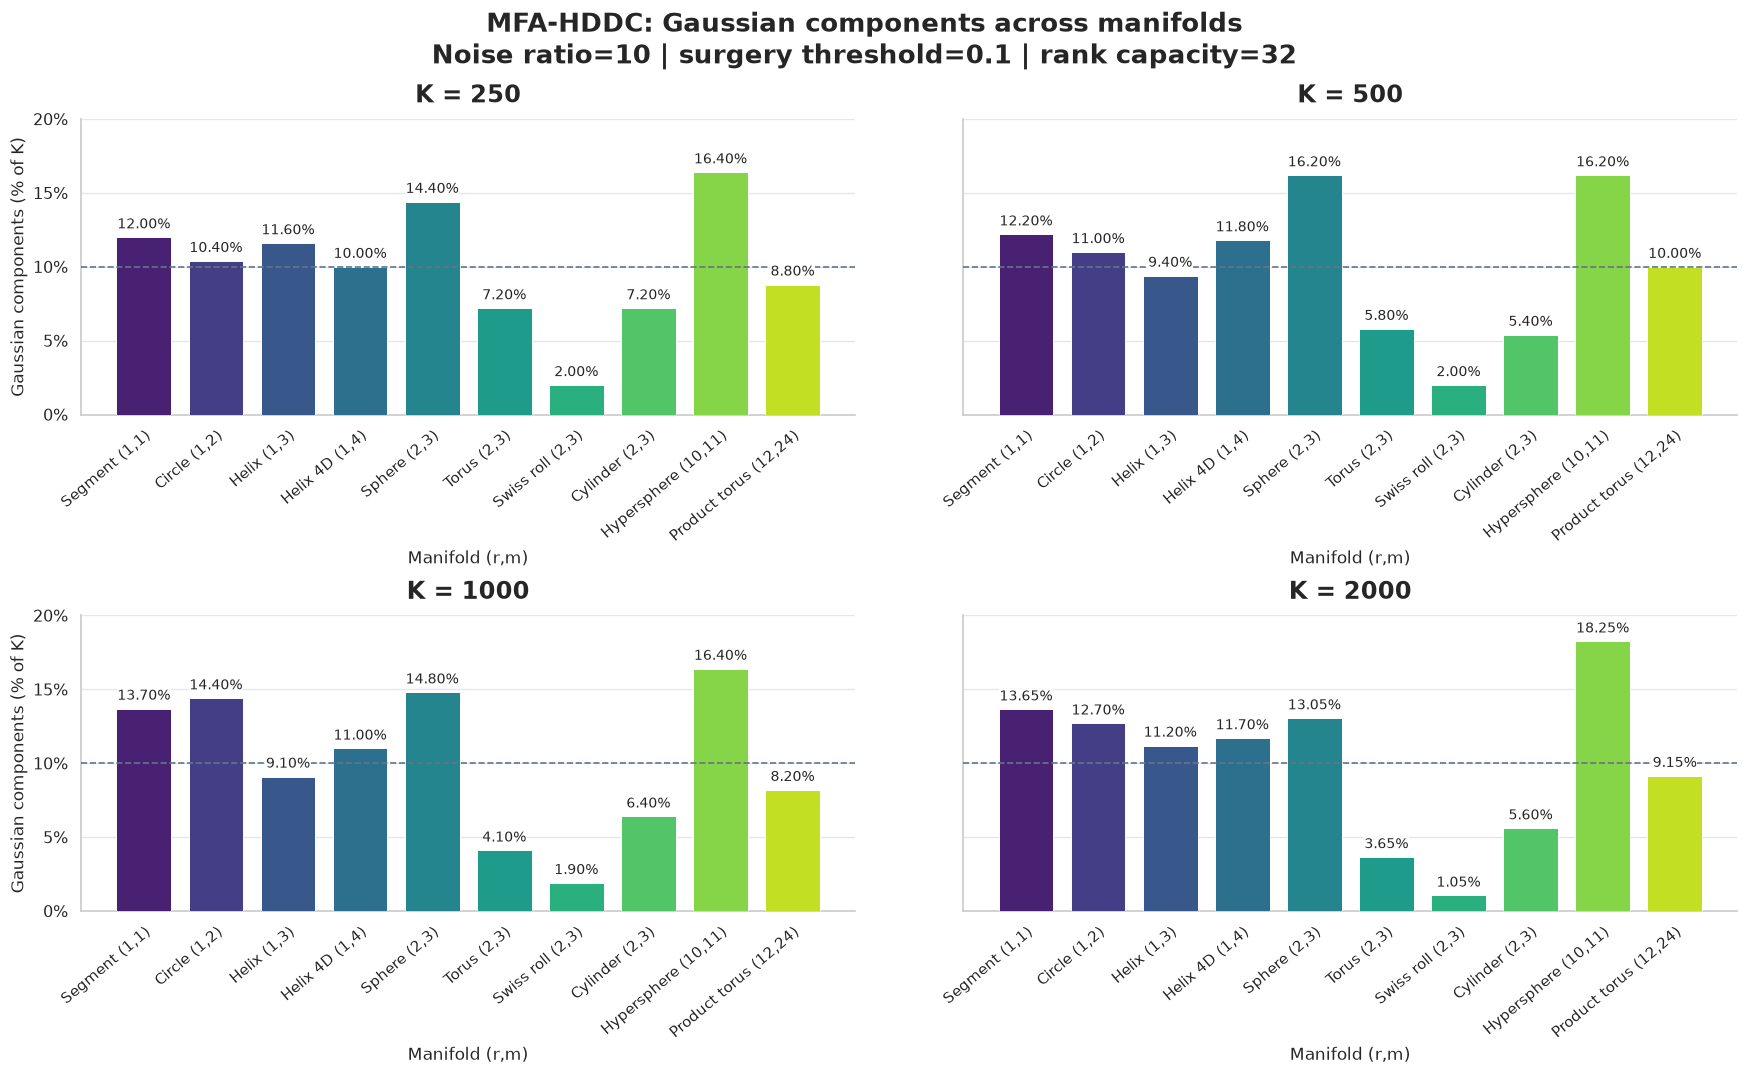

Saved component-allocation figure and CSV tables to outputs/experiments/toy_noise_sweep_metrics/plots


In [52]:
from matplotlib.ticker import PercentFormatter

HDDC_ALLOCATION_YMAX = 20
assert hddc_allocation_pct.max().max() < HDDC_ALLOCATION_YMAX - 1
sns.set_theme(style="whitegrid", context="notebook", font_scale=1.05)
hddc_allocation_fig, hddc_allocation_axes = plt.subplots(
    2, 2, figsize=(18, 11), sharex=True, sharey=True,
)
hddc_allocation_fig.subplots_adjust(
    left=0.065, right=0.985, bottom=0.15, top=0.87, hspace=0.68, wspace=0.14,
)
hddc_allocation_colors = sns.color_palette("viridis", n_colors=len(catalog))
for ax, k in zip(hddc_allocation_axes.flat, hddc_allocation_ks):
    values = hddc_allocation_pct[k].to_numpy()
    bars = ax.bar(
        np.arange(len(catalog)), values, width=0.76,
        color=hddc_allocation_colors, edgecolor="white", linewidth=0.7, zorder=3,
    )
    ax.axhline(100 / len(catalog), color="#64748b", linestyle="--", linewidth=1.2, zorder=4)
    ax.bar_label(bars, labels=[f"{value:.2f}%" for value in values], padding=4, fontsize=10,
        zorder=5, bbox={"facecolor": "white", "edgecolor": "none", "pad": 0.5})
    ax.set_title(f"K = {k}", fontsize=17, fontweight="bold", pad=12)
    ax.set_xticks(np.arange(len(catalog)), hddc_allocation_pct.index)
    ax.tick_params(axis="x", labelbottom=True)
    plt.setp(ax.get_xticklabels(), rotation=40, ha="right", rotation_mode="anchor", fontsize=11)
    ax.set_ylim(0, HDDC_ALLOCATION_YMAX)
    ax.set_yticks(np.arange(0, HDDC_ALLOCATION_YMAX + 1, 5))
    ax.yaxis.set_major_formatter(PercentFormatter(xmax=100, decimals=0))
    ax.grid(axis="y", color="#e2e8f0", zorder=0)
    ax.grid(axis="x", visible=False)
    ax.set_xlabel("Manifold (r,m)")
for ax in hddc_allocation_axes[:, 0]:
    ax.set_ylabel("Gaussian components (% of K)")
sns.despine(fig=hddc_allocation_fig)
hddc_allocation_fig.suptitle(
    "MFA-HDDC: Gaussian components across manifolds\n"
    f"Noise ratio={HDDC_ALLOCATION_NOISE_RATIO:g} | surgery threshold={HDDC_ALLOCATION_THRESHOLD:g} | "
    f"rank capacity={HDDC_ALLOCATION_Q_CAPACITY}",
    fontsize=19, fontweight="bold", y=0.97,
)

PLOT_DIR.mkdir(parents=True, exist_ok=True)
hddc_allocation_threshold_tag = f"{HDDC_ALLOCATION_THRESHOLD:g}".replace(".", "p")
hddc_allocation_stem = (
    f"hddc_noise{HDDC_ALLOCATION_NOISE_RATIO:g}_q{HDDC_ALLOCATION_Q_CAPACITY}_"
    f"threshold{hddc_allocation_threshold_tag}_component_allocation"
)
for suffix in ("png", "pdf"):
    hddc_allocation_fig.savefig(
        PLOT_DIR / f"{hddc_allocation_stem}.{suffix}", dpi=250, bbox_inches="tight", facecolor="white",
    )
hddc_allocation_pct.to_csv(PLOT_DIR / f"{hddc_allocation_stem}_percentages.csv")
hddc_allocation_by_type[[
    "evaluation_id", "model_kind", "K", "noise_ratio", "surgery_threshold", "q_capacity",
    "seed", "split_seed", "dataset_seed", "manifold_id", "type_name", "intrinsic_dim", "embedding_dim",
    *hddc_allocation_count_columns, "component_pct", "source_path", "source_sha256",
]].sort_values(["K", "intrinsic_dim", "embedding_dim", "manifold_id"]).to_csv(
    PLOT_DIR / f"{hddc_allocation_stem}_per_manifold.csv", index=False,
)
plt.show()
print(f"Saved component-allocation figure and CSV tables to {PLOT_DIR.relative_to(REPO)}")


## Vanilla MFA: Gaussian components across manifolds

Repeat the component-allocation plot for **vanilla MFA**, fixing **noise ratio
10** and **configured rank 32**, for **K=250, 500, 1000, 2000** (training seed
42). Vanilla MFA has no surgery threshold.

Each bar shows $p_i = 100\,N_i/K$, where $N_i$ is the saved per-manifold
`components__associated` count. A Gaussian is associated with the **unique
nearest noiseless manifold to its mean**, using exact mean-to-manifold
projection and no distance cutoff. Every component has equal weight,
regardless of its mixture weight, effective rank, or hard-assignment count.

All K components are included, even those with no hard-assigned points:
**11, 12, 26, and 32** for the four ascending K values. Each run has ten
manifold types and all components have an unambiguous association, so each
panel sums to **100%**. The saved geometric allocation counts match the
MFA-HDDC surgery-threshold-0.1 counts at every K; hard-assignment activity
differs between the models.

The layout, manifold order, colors, **0–20%** scale, and dashed **10%**
equal-allocation reference match the preceding MFA-HDDC figure. Labels show
**(intrinsic dimension, native embedding dimension)**, and **Segment** is the
straight-line manifold. PNG/PDF figures, a percentage grid, and per-manifold
counts with provenance are saved under `PLOT_DIR` with prefix
`mfa_noise10_q32_component_allocation`.


In [53]:
MFA_ALLOCATION_NOISE_RATIO = 10
MFA_ALLOCATION_Q_CAPACITY = 32
mfa_allocation_runs = overall.loc[
    overall["model_kind"].eq("mfa")
    & overall["noise_ratio"].eq(MFA_ALLOCATION_NOISE_RATIO)
    & overall["q_capacity"].eq(MFA_ALLOCATION_Q_CAPACITY)
].sort_values("K").copy()
assert mfa_allocation_runs["surgery_threshold"].isna().all()
assert mfa_allocation_runs["K"].is_unique, "Each K must have exactly one evaluation."
assert mfa_allocation_runs["K"].tolist() == [250, 500, 1000, 2000]
assert mfa_allocation_runs[["seed", "split_seed", "dataset_seed"]].nunique(dropna=False).eq(1).all()
assert mfa_allocation_runs["association__rule"].eq("unique_nearest_exact_projection").all()
assert mfa_allocation_runs["association__max_mean_to_manifold_distance"].isna().all()
assert mfa_allocation_runs[[
    "association__ambiguous_components", "association__outside_cutoff_components",
]].eq(0).all().all()
assert mfa_allocation_runs["association__associated_components"].eq(mfa_allocation_runs["K"]).all()

mfa_allocation_by_type = manifolds.loc[
    manifolds["evaluation_id"].isin(mfa_allocation_runs["evaluation_id"])
].copy()
assert not mfa_allocation_by_type.duplicated(["evaluation_id", "manifold_id"]).any()
assert not mfa_allocation_by_type.duplicated(["evaluation_id", "type_name"]).any()
mfa_allocation_count_columns = [
    "components__associated", "components__assignment_live", "components__assignment_dead",
]
for column in mfa_allocation_count_columns:
    counts = mfa_allocation_by_type[column]
    assert counts.notna().all() and counts.ge(0).all() and counts.mod(1).eq(0).all()
    mfa_allocation_by_type[column] = counts.astype(int)
assert mfa_allocation_by_type["components__associated"].eq(
    mfa_allocation_by_type["components__assignment_live"]
    + mfa_allocation_by_type["components__assignment_dead"]
).all()
for _, run in mfa_allocation_runs.iterrows():
    per_type = mfa_allocation_by_type.loc[mfa_allocation_by_type["evaluation_id"].eq(run["evaluation_id"])]
    assert len(per_type) == 10
    assert dict(zip(per_type["manifold_id"], per_type["type_name"])) == dict(zip(catalog["manifold_id"], catalog["type_name"]))
    assert per_type["components__associated"].sum() == run["K"]
    assert per_type["components__assignment_live"].sum() == run["components__live"]
    assert per_type["components__assignment_dead"].sum() == run["components__dead"]

# Use all K components as the denominator, including assignment-dead components.
mfa_allocation_by_type["component_pct"] = (
    100.0 * mfa_allocation_by_type["components__associated"] / mfa_allocation_by_type["K"]
)
mfa_allocation_ks = mfa_allocation_runs["K"].astype(int).tolist()
mfa_allocation_pct = mfa_allocation_by_type.pivot(
    index="manifold_id", columns="K", values="component_pct",
).reindex(index=row_ids, columns=mfa_allocation_ks).astype(float)
mfa_allocation_pct.index = pd.Index(catalog["label"].tolist(), name="Manifold (r,m)")
assert mfa_allocation_pct.notna().all().all()
assert np.isfinite(mfa_allocation_pct.to_numpy()).all()
assert mfa_allocation_pct.ge(0).all().all() and mfa_allocation_pct.le(100).all().all()
assert np.allclose(mfa_allocation_pct.sum(axis=0), 100.0)
print("Vanilla MFA component allocation: K=" + ", ".join(map(str, mfa_allocation_ks)))
print("All 40 manifold counts are present; each panel sums to 100% of K.")


Vanilla MFA component allocation: K=250, 500, 1000, 2000
All 40 manifold counts are present; each panel sums to 100% of K.


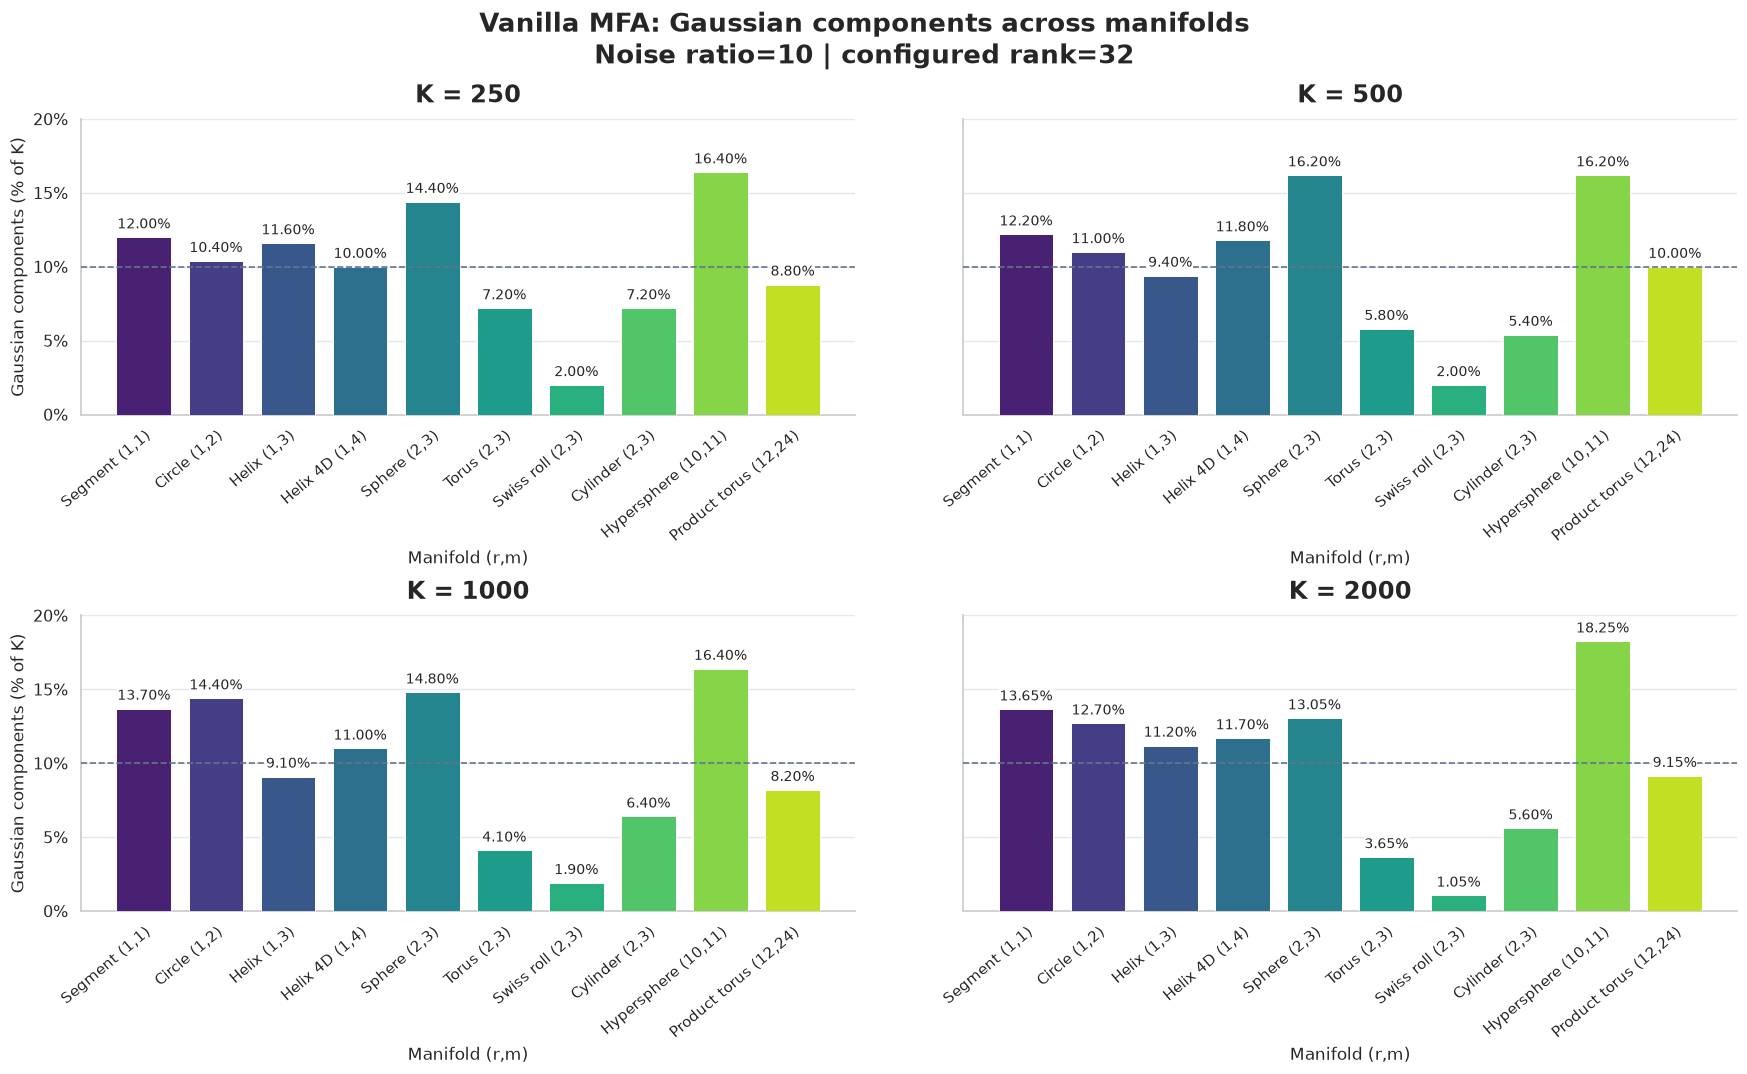

Saved component-allocation figure and CSV tables to outputs/experiments/toy_noise_sweep_metrics/plots


In [54]:
from matplotlib.ticker import PercentFormatter

MFA_ALLOCATION_YMAX = 20
assert mfa_allocation_pct.max().max() < MFA_ALLOCATION_YMAX - 1
sns.set_theme(style="whitegrid", context="notebook", font_scale=1.05)
mfa_allocation_fig, mfa_allocation_axes = plt.subplots(
    2, 2, figsize=(18, 11), sharex=True, sharey=True,
)
mfa_allocation_fig.subplots_adjust(
    left=0.065, right=0.985, bottom=0.15, top=0.87, hspace=0.68, wspace=0.14,
)
mfa_allocation_colors = sns.color_palette("viridis", n_colors=len(catalog))
for ax, k in zip(mfa_allocation_axes.flat, mfa_allocation_ks):
    values = mfa_allocation_pct[k].to_numpy()
    bars = ax.bar(
        np.arange(len(catalog)), values, width=0.76,
        color=mfa_allocation_colors, edgecolor="white", linewidth=0.7, zorder=3,
    )
    ax.axhline(100 / len(catalog), color="#64748b", linestyle="--", linewidth=1.2, zorder=4)
    ax.bar_label(bars, labels=[f"{value:.2f}%" for value in values], padding=4, fontsize=10,
        zorder=5, bbox={"facecolor": "white", "edgecolor": "none", "pad": 0.5})
    ax.set_title(f"K = {k}", fontsize=17, fontweight="bold", pad=12)
    ax.set_xticks(np.arange(len(catalog)), mfa_allocation_pct.index)
    ax.tick_params(axis="x", labelbottom=True)
    plt.setp(ax.get_xticklabels(), rotation=40, ha="right", rotation_mode="anchor", fontsize=11)
    ax.set_ylim(0, MFA_ALLOCATION_YMAX)
    ax.set_yticks(np.arange(0, MFA_ALLOCATION_YMAX + 1, 5))
    ax.yaxis.set_major_formatter(PercentFormatter(xmax=100, decimals=0))
    ax.grid(axis="y", color="#e2e8f0", zorder=0)
    ax.grid(axis="x", visible=False)
    ax.set_xlabel("Manifold (r,m)")
for ax in mfa_allocation_axes[:, 0]:
    ax.set_ylabel("Gaussian components (% of K)")
sns.despine(fig=mfa_allocation_fig)
mfa_allocation_fig.suptitle(
    "Vanilla MFA: Gaussian components across manifolds\n"
    f"Noise ratio={MFA_ALLOCATION_NOISE_RATIO:g} | "
    f"configured rank={MFA_ALLOCATION_Q_CAPACITY}",
    fontsize=19, fontweight="bold", y=0.97,
)

PLOT_DIR.mkdir(parents=True, exist_ok=True)
mfa_allocation_stem = (
    f"mfa_noise{MFA_ALLOCATION_NOISE_RATIO:g}_q{MFA_ALLOCATION_Q_CAPACITY}_component_allocation"
)
for suffix in ("png", "pdf"):
    mfa_allocation_fig.savefig(
        PLOT_DIR / f"{mfa_allocation_stem}.{suffix}", dpi=250, bbox_inches="tight", facecolor="white",
    )
mfa_allocation_pct.to_csv(PLOT_DIR / f"{mfa_allocation_stem}_percentages.csv")
mfa_allocation_by_type[[
    "evaluation_id", "model_kind", "K", "noise_ratio", "q_capacity",
    "seed", "split_seed", "dataset_seed", "manifold_id", "type_name", "intrinsic_dim", "embedding_dim",
    *mfa_allocation_count_columns, "component_pct", "source_path", "source_sha256",
]].sort_values(["K", "intrinsic_dim", "embedding_dim", "manifold_id"]).to_csv(
    PLOT_DIR / f"{mfa_allocation_stem}_per_manifold.csv", index=False,
)
plt.show()
print(f"Saved component-allocation figure and CSV tables to {PLOT_DIR.relative_to(REPO)}")


## K-means + PCA: components across manifolds

Repeat the allocation plot for **K-means + PCA** at **noise ratio 10**, with
one saved partition for each **K=250, 500, 1000, 2000** (K-means seed 0).
Each bar shows $p_i = 100\,N_i/K$, where $N_i$ is the per-manifold
`components__associated` count. A centroid is associated with the **unique
nearest noiseless manifold**, using exact centroid-to-manifold projection
and no distance cutoff. Every centroid has equal weight, independently of
cluster size and selected PCA rank.

Use **all K centroids**, including clusters below the PCA-scoring population
cutoff. The stored `components__eligible_associated` counts refer to that
smaller scoring population and are not used for these bars. All centroids
are associated unambiguously and have at least one assigned point, so the
ten bars in each panel sum to **100%**.

Each partition has nine Cattell-threshold evaluation records. Select
**Cattell threshold 0.01** once per K and verify that the allocation counts
are identical across all nine records. The saved PCA capacities are
**32, 32, 16, 32** for ascending K; PCA capacity and Cattell threshold do not
enter the centroid-association calculation, so all four partitions can be
shown together for this metric.

The manifold order, colors, **0–20%** scale, and dashed **10%** equal-allocation
reference match the MFA figures. Labels show **(intrinsic dimension, native
embedding dimension)** using the notebook's shared dataset catalog;
**Segment** is the straight-line manifold. PNG/PDF figures, a percentage
grid, and per-manifold counts with provenance are saved under `PLOT_DIR`
with prefix `kmeans_noise10_component_allocation`.


In [55]:
KM_ALLOCATION_NOISE_RATIO = 10
KM_ALLOCATION_CATTELL_THRESHOLD = 0.01
km_allocation_runs = overall.loc[
    overall["model_kind"].eq("kmeans")
    & overall["noise_ratio"].eq(KM_ALLOCATION_NOISE_RATIO)
    & overall["cattell_threshold"].eq(KM_ALLOCATION_CATTELL_THRESHOLD)
].sort_values("K").copy()
assert km_allocation_runs["surgery_threshold"].isna().all()
assert km_allocation_runs["K"].is_unique, "Each K must have exactly one evaluation."
assert km_allocation_runs["K"].tolist() == [250, 500, 1000, 2000]
assert km_allocation_runs[["seed", "split_seed", "dataset_seed"]].nunique(dropna=False).eq(1).all()
assert km_allocation_runs["association__population"].eq("all_saved_kmeans_centroids").all()
assert km_allocation_runs["components__dead"].eq(0).all()
assert km_allocation_runs["association__rule"].eq("unique_nearest_exact_projection").all()
assert km_allocation_runs["association__max_mean_to_manifold_distance"].isna().all()
assert km_allocation_runs[[
    "association__ambiguous_components", "association__outside_cutoff_components",
]].eq(0).all().all()
assert km_allocation_runs["association__associated_components"].eq(km_allocation_runs["K"]).all()

# Cattell records repeat one partition; association counts must not change.
km_allocation_repeats = manifolds.loc[
    manifolds["model_kind"].eq("kmeans")
    & manifolds["noise_ratio"].eq(KM_ALLOCATION_NOISE_RATIO)
    & manifolds["run_id"].isin(km_allocation_runs["run_id"])
]
assert km_allocation_repeats.groupby(["run_id", "manifold_id"])[
    "components__associated"
].nunique(dropna=False).eq(1).all()

km_allocation_by_type = manifolds.loc[
    manifolds["evaluation_id"].isin(km_allocation_runs["evaluation_id"])
].copy()
# KM reports omit native dimensions; use the shared dataset catalog for labels.
km_allocation_by_type["embedding_dim"] = km_allocation_by_type["manifold_id"].map(
    catalog.set_index("manifold_id")["embedding_dim"]
)
assert not km_allocation_by_type.duplicated(["evaluation_id", "manifold_id"]).any()
assert not km_allocation_by_type.duplicated(["evaluation_id", "type_name"]).any()
km_allocation_count_columns = [
    "components__associated", "components__assignment_live", "components__assignment_dead",
]
for column in km_allocation_count_columns:
    counts = km_allocation_by_type[column]
    assert counts.notna().all() and counts.ge(0).all() and counts.mod(1).eq(0).all()
    km_allocation_by_type[column] = counts.astype(int)
assert km_allocation_by_type["components__associated"].eq(
    km_allocation_by_type["components__assignment_live"]
    + km_allocation_by_type["components__assignment_dead"]
).all()
for _, run in km_allocation_runs.iterrows():
    per_type = km_allocation_by_type.loc[km_allocation_by_type["evaluation_id"].eq(run["evaluation_id"])]
    assert len(per_type) == 10
    assert dict(zip(per_type["manifold_id"], per_type["type_name"])) == dict(zip(catalog["manifold_id"], catalog["type_name"]))
    assert per_type["components__associated"].sum() == run["K"]
    assert per_type["components__assignment_live"].sum() == run["components__live"]
    assert per_type["components__assignment_dead"].sum() == run["components__dead"]

# Count all K centroids, including clusters ineligible for PCA scoring.
km_allocation_by_type["component_pct"] = (
    100.0 * km_allocation_by_type["components__associated"] / km_allocation_by_type["K"]
)
km_allocation_ks = km_allocation_runs["K"].astype(int).tolist()
km_allocation_pct = km_allocation_by_type.pivot(
    index="manifold_id", columns="K", values="component_pct",
).reindex(index=row_ids, columns=km_allocation_ks).astype(float)
km_allocation_pct.index = pd.Index(catalog["label"].tolist(), name="Manifold (r,m)")
assert km_allocation_pct.notna().all().all()
assert np.isfinite(km_allocation_pct.to_numpy()).all()
assert km_allocation_pct.ge(0).all().all() and km_allocation_pct.le(100).all().all()
assert np.allclose(km_allocation_pct.sum(axis=0), 100.0)
print("K-means + PCA component allocation: K=" + ", ".join(map(str, km_allocation_ks)))
print("All 40 manifold counts are present; each panel sums to 100% of K.")
print("Saved PCA capacities by K:")
print(km_allocation_runs.set_index("K")["pca_capacity"].to_string())


K-means + PCA component allocation: K=250, 500, 1000, 2000
All 40 manifold counts are present; each panel sums to 100% of K.
Saved PCA capacities by K:
K
250     32
500     32
1000    16
2000    32


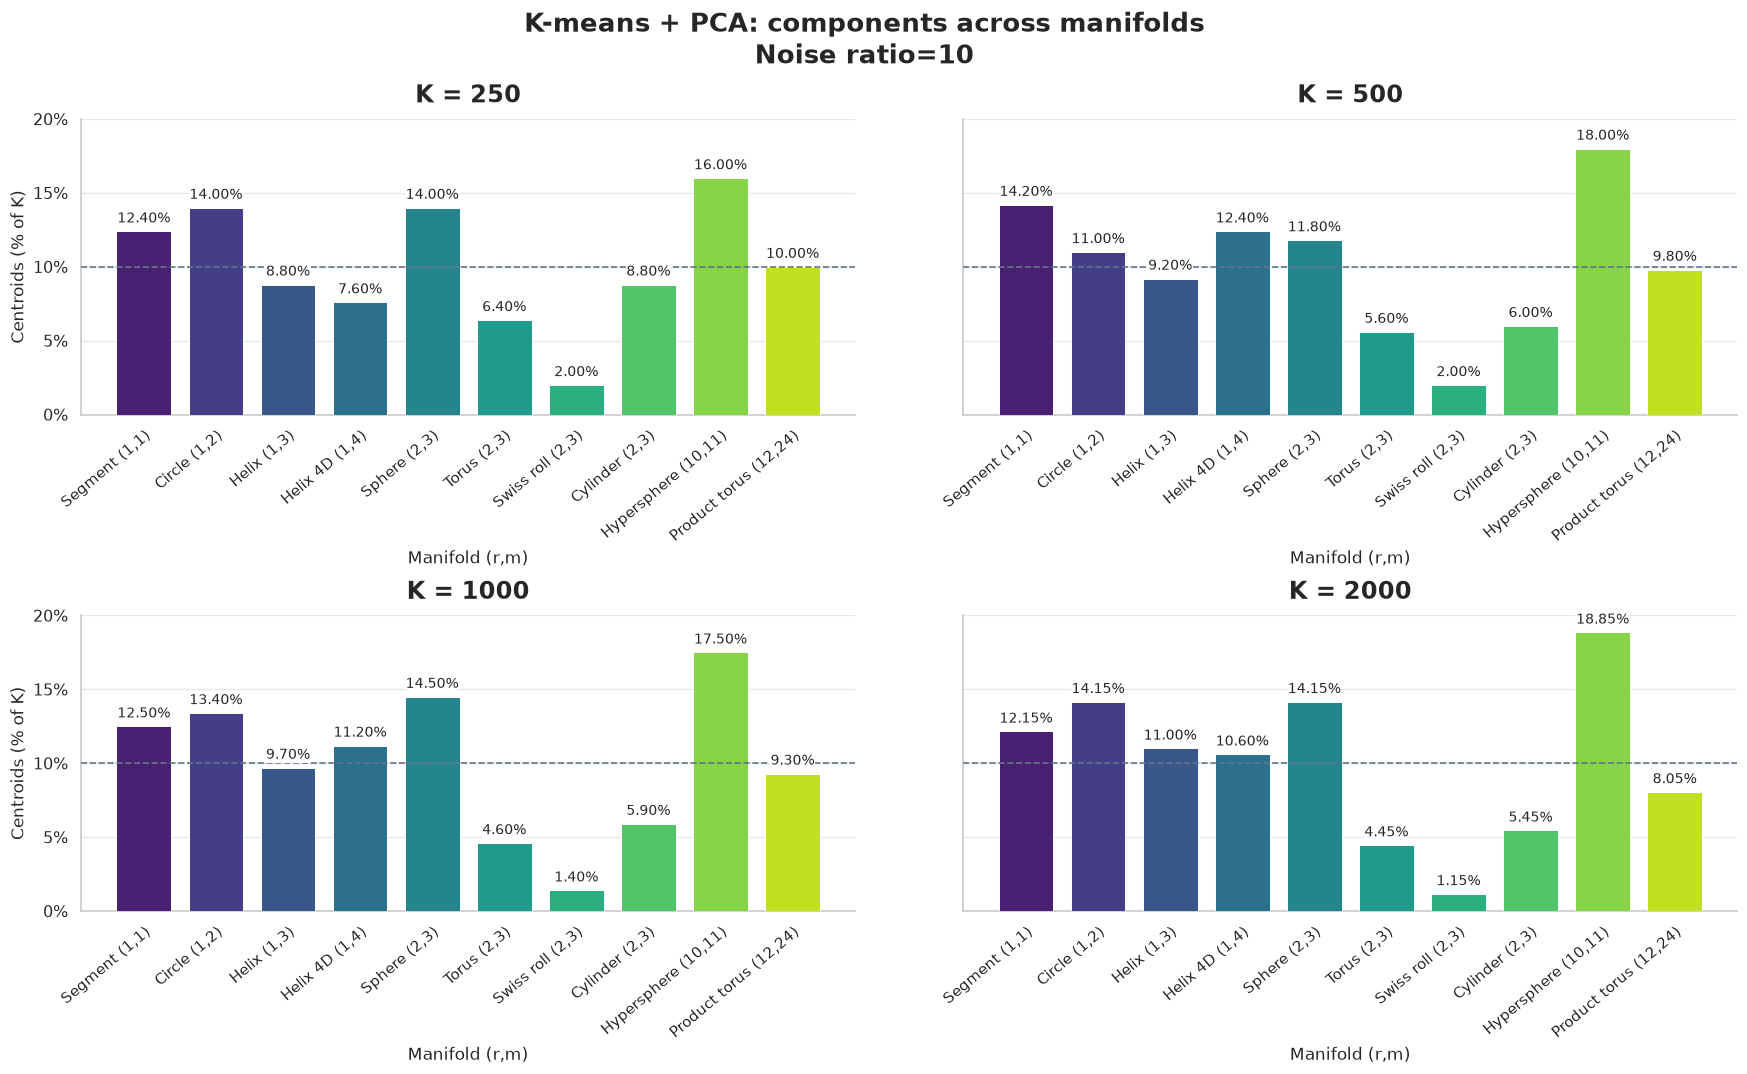

Saved component-allocation figure and CSV tables to outputs/experiments/toy_noise_sweep_metrics/plots


In [56]:
from matplotlib.ticker import PercentFormatter

KM_ALLOCATION_YMAX = 20
assert km_allocation_pct.max().max() < KM_ALLOCATION_YMAX - 1
sns.set_theme(style="whitegrid", context="notebook", font_scale=1.05)
km_allocation_fig, km_allocation_axes = plt.subplots(
    2, 2, figsize=(18, 11), sharex=True, sharey=True,
)
km_allocation_fig.subplots_adjust(
    left=0.065, right=0.985, bottom=0.15, top=0.87, hspace=0.68, wspace=0.14,
)
km_allocation_colors = sns.color_palette("viridis", n_colors=len(catalog))
for ax, k in zip(km_allocation_axes.flat, km_allocation_ks):
    values = km_allocation_pct[k].to_numpy()
    bars = ax.bar(
        np.arange(len(catalog)), values, width=0.76,
        color=km_allocation_colors, edgecolor="white", linewidth=0.7, zorder=3,
    )
    ax.axhline(100 / len(catalog), color="#64748b", linestyle="--", linewidth=1.2, zorder=4)
    ax.bar_label(bars, labels=[f"{value:.2f}%" for value in values], padding=4, fontsize=10,
        zorder=5, bbox={"facecolor": "white", "edgecolor": "none", "pad": 0.5})
    ax.set_title(f"K = {k}", fontsize=17, fontweight="bold", pad=12)
    ax.set_xticks(np.arange(len(catalog)), km_allocation_pct.index)
    ax.tick_params(axis="x", labelbottom=True)
    plt.setp(ax.get_xticklabels(), rotation=40, ha="right", rotation_mode="anchor", fontsize=11)
    ax.set_ylim(0, KM_ALLOCATION_YMAX)
    ax.set_yticks(np.arange(0, KM_ALLOCATION_YMAX + 1, 5))
    ax.yaxis.set_major_formatter(PercentFormatter(xmax=100, decimals=0))
    ax.grid(axis="y", color="#e2e8f0", zorder=0)
    ax.grid(axis="x", visible=False)
    ax.set_xlabel("Manifold (r,m)")
for ax in km_allocation_axes[:, 0]:
    ax.set_ylabel("Centroids (% of K)")
sns.despine(fig=km_allocation_fig)
km_allocation_fig.suptitle(
    "K-means + PCA: components across manifolds\n"
    f"Noise ratio={KM_ALLOCATION_NOISE_RATIO:g}",
    fontsize=19, fontweight="bold", y=0.97,
)

PLOT_DIR.mkdir(parents=True, exist_ok=True)
km_allocation_stem = (
    f"kmeans_noise{KM_ALLOCATION_NOISE_RATIO:g}_component_allocation"
)
for suffix in ("png", "pdf"):
    km_allocation_fig.savefig(
        PLOT_DIR / f"{km_allocation_stem}.{suffix}", dpi=250, bbox_inches="tight", facecolor="white",
    )
km_allocation_pct.to_csv(PLOT_DIR / f"{km_allocation_stem}_percentages.csv")
km_allocation_by_type[[
    "evaluation_id", "model_kind", "K", "noise_ratio", "pca_capacity", "cattell_threshold",
    "seed", "split_seed", "dataset_seed", "manifold_id", "type_name", "intrinsic_dim", "embedding_dim",
    *km_allocation_count_columns, "components__eligible_associated",
    "components__excluded_below_min_population", "component_pct", "source_path", "source_sha256",
]].sort_values(["K", "intrinsic_dim", "embedding_dim", "manifold_id"]).to_csv(
    PLOT_DIR / f"{km_allocation_stem}_per_manifold.csv", index=False,
)
plt.show()
print(f"Saved component-allocation figure and CSV tables to {PLOT_DIR.relative_to(REPO)}")
